In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [62]:
# Create the destination path
#!mkdir -p /content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2/RESULT

# Move the directory
!cp -r /content/bundles /content/drive/MyDrive/HyperN/bundles

In [4]:
!pip install wordfreq gensim datasketch LTNtorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 18.5 MB/s eta 0:00:00


In [ ]:
!pip install git+https://github.com/IBM/LNN

In [5]:
import nltk

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## DS loading


In [ ]:
!python cooc_prob_wiki8.3.1.py --corpus enwik8 --ppmi --shift 5 --output ./wiki_cooc_w5-20_minfreq10_ppmi_shift_5.npz

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
Building co-occurrence matrix:
  Corpus: enwik8
  Window: 5-19
  Minimum frequency: 10
  Max chars: All
  Disk-backed: False

Traceback (most recent call last):
  File "/content/cooc_prob_wiki8.3.1.py", line 644, in <module>
    wiki_path = cooc.download_wiki(corpus=args.corpus, data_dir=args.data_dir)
object address  : 0x7c5ca39a3ca0
object refcount : 3
object type     : 0xa2a4e0
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr
^C


In [7]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/HyperN/DATA/Default/train_hypernyms.csv')
test_df = pd.read_csv('/content/drive/MyDrive/HyperN/DATA/Default/test_hypernyms.csv')
neg_df = pd.read_csv('/content/drive/MyDrive/HyperN/DATA/Default/non_hypernyms.csv')


train_pairs = train_df.values
test_pairs = test_df.values
neg_pairs = neg_df.values

print("Training pairs:")
print(train_pairs[:5])

print("Testing pairs:")
print(test_pairs[:5])

print("Negative pairs:")
print(neg_pairs[:5])

Training pairs:
[['supermarket' 'commercial building']
 ['hand tool' 'tool']
 ['peach' 'fruit']
 ['pike' 'fish']
 ['nail gun' 'power tool']]
Testing pairs:
[['workshop' 'building']
 ['train' 'vehicle']
 ['pine' 'physical object']
 ['snare drum' 'physical object']
 ['grape' 'physical object']]
Negative pairs:
[['jigsaw' 'nail gun']
 ['temple' 'synagogue']
 ['double bass' 'banjo']
 ['turkey' 'turkey']
 ['crocodile' 'snake']]


####  Codeword Tensor: Hierarchy only

In [8]:
!python /content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2/build_wn_codeword_tensor_ds_1.py \
  --out wn_tensors.pt \
  --root_type noun \
  --with_freq 0

Saved: wn_tensors.pt
N=82115  T_max=18  D=3


#### Codeword tensor:  Hierarchy x Frequency

In [9]:
!python /content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2/build_wn_codeword_tensor_ds_1.py \
  --out wn_tensors_freq.pt \
  --root_type noun \
  --with_freq 1 \
  --cooc_npz /content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2/wiki_cooc_w5-20_minfreq10_ppmi_shift_5.npz

Saved: wn_tensors_freq.pt
N=82115  T_max=18  D=3


In [10]:
!python /content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2/train_wordnet_katz_directed_d25.py \
  --train_csv /content/drive/MyDrive/HyperN/DATA/Default/train_hypernyms.csv \
  --neg_csv /content/drive/MyDrive/HyperN/DATA/Default/non_hypernyms.csv \
  --out_dir ./wordnet_katz_directed_d25 \
  --dim 25 \
  --alpha 0.8 \
  --K 10 \
  --tol 1e-5 \
  --prune_topk 400 \
  --use_shifted_ppmi \
  --shift_k 5.0 \
  --seed 0

Saved to: wordnet_katz_directed_d25
Explained variance (TruncatedSVD sum): 0.2295709103345871


In [14]:
import sys

# Add the directory to Python path
sys.path.insert(0, '/content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2/')

# Now you can import the function
from load_modules_from_directory import load_modules_from_directory as l


In [12]:
modules = l.load_modules_from_directory(
    "/content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2/",
    verbose=True
)

✓ Added to sys.path: /content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2

Found 11 Python files:
  - Poincare_DS_1.py
  - WN_arithmetic_interval_encoding8_5.py
  - build_wn_codeword_tensor_ds_1.py
  - cooc_prob_wiki8.3.1.py
  - eval_bundles.py
  - katz_complete_closure_1_2.py
  - load_modules_from_directory.py
  - make_wn_cooc_datasets_v3_trainlabels.py
  - train_closure_completion.py
  - train_wordnet_katz_directed_d25.py
  - wn_cooc_feature_pipeline_v7.py

✓ Loaded: Poincare_DS_1
✓ Loaded: WN_arithmetic_interval_encoding8_5
✓ Loaded: build_wn_codeword_tensor_ds_1


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✓ Loaded (direct): cooc_prob_wiki8.3.1
✓ Loaded: eval_bundles
✓ Loaded: katz_complete_closure_1_2
✓ Reloaded: load_modules_from_directory
✓ Loaded: make_wn_cooc_datasets_v3_trainlabels
✓ Loaded: train_closure_completion
✓ Loaded: train_wordnet_katz_directed_d25
✓ Reloaded: wn_cooc_feature_pipeline_v7

Summary: 11/11 modules loaded successfully



Boolean labels from default DS closure - reachability from terms coocurances.   

In [15]:
from train_closure_completion import make_train_closure

train_cl = make_train_closure(train_df, label_col="label")
y_test_rowpath = train_cl.label_pairs(test_df, max_depth=None)

Path closure based-on Katz centrality - reachablity from factorized terms adjacency matrix   

In [16]:
import numpy as np
from katz_complete_closure_1_2 import (
    build_csr_adjacency_from_edges,
    katz_truncated_scores,
)

import numpy as np
from katz_complete_closure_1_2 import (
    build_csr_adjacency_from_edges,
    katz_truncated_scores,
)

def _norm(x: str) -> str:
    return str(x).strip()

def katz_scores_for_pairs(pairs_df, S, idx, hypo_col="hypo", hyper_col="hyper"):
    scores = np.zeros(len(pairs_df), dtype=np.float32)
    for t, (h, H) in enumerate(zip(pairs_df[hypo_col].astype(str), pairs_df[hyper_col].astype(str))):
        i = idx.get(_norm(h))
        j = idx.get(_norm(H))
        if i is None or j is None:
            scores[t] = 0.0
        else:
            scores[t] = float(S[i, j])  # 0 if not present
    return scores

def _norm(x: str) -> str:
    return str(x).strip()

def katz_scores_for_pairs(pairs_df, S, idx, hypo_col="hypo", hyper_col="hyper"):
    scores = np.zeros(len(pairs_df), dtype=np.float32)
    for t, (h, H) in enumerate(zip(pairs_df[hypo_col].astype(str), pairs_df[hyper_col].astype(str))):
        i = idx.get(_norm(h))
        j = idx.get(_norm(H))
        if i is None or j is None:
            scores[t] = 0.0
        else:
            scores[t] = float(S[i, j])  # 0 if not present
    return scores

#### Katz scores from the original TRAIN adjacency

In [17]:
# 1) TRAIN adjacency
M, nodes, idx = build_csr_adjacency_from_edges(train_df, label_col="label")

# 2) Katz score matrix (truncated)
S = katz_truncated_scores(M.tocsr(), alpha=0.01, k_max=5).tocsr()

# 3) Scores for train/test pairs
katz_scores_train = katz_scores_for_pairs(train_df, S, idx)
katz_scores_test  = katz_scores_for_pairs(test_df,  S, idx)

#### Katz scores after graph completion

In [18]:
from katz_complete_closure_1_2 import katz_complete_graph, katz_truncated_scores

# Complete adjacency
M_katz = katz_complete_graph(M, alpha=0.01, k_max=5, top_k_per_row=10, n_rounds=2)

# Katz scores on the completed adjacency
S_completed = katz_truncated_scores(M_katz.astype(np.float32).tocsr(), alpha=0.01, k_max=5).tocsr()

katz_scores_train_c = katz_scores_for_pairs(train_df, S_completed, idx)
katz_scores_test_c  = katz_scores_for_pairs(test_df,  S_completed, idx)

##### Minimal trainig code for hyperbolic embedding on seminar data.  WorNet hyperbolic embeddings have been trained with the full code adopted from https://github.com/harmanpreet93/poincare-embedding-using-gensim/blob/master/poincare-embeddings-using-gensim.ipynb

In [19]:
from gensim.models.poincare import PoincareModel
from pathlib import Path
import csv
import numpy as np

train_path = Path("/content/drive/MyDrive/HyperN/DATA/Default/train_hypernyms.csv")
nonhyper_path = Path("/content/drive/MyDrive/HyperN/DATA/Default//non_hypernyms.csv")

def load_pairs(path: Path, sep: str | None = None, has_header: bool = True):
    """
    Loads (child, parent) pairs from a 2-column CSV/TSV.
    - sep=None -> auto-detect by file suffix (.tsv => '\t', else ',')
    - has_header=True -> skips first row
    """
    if sep is None:
        sep = "\t" if path.suffix.lower() == ".tsv" else ","

    pairs = []
    with path.open("r", encoding="utf-8", newline="") as f:
        reader = csv.reader(f, delimiter=sep)
        if has_header:
            next(reader, None)
        for row in reader:
            if not row or len(row) < 2:
                continue
            child = row[0].strip()
            parent = row[1].strip()
            if child and parent:
                pairs.append((child, parent))
    return pairs

# 1) Load positive (train) hypernym relations
train_relations = load_pairs(train_path, sep=None, has_header=True)
nonhyper_relations = load_pairs(nonhyper_path, sep=None, has_header=True)

# 2) Train Poincaré embeddings on positives only
model = PoincareModel(
    nonhyper_relations,
    size=50,
    negative=10,    # internal negative samples per positive
    burn_in=10,     # stabilize early training
    alpha=0.1,      # LR (tune)
    seed=42
)
model.train(epochs=50)

# 3) Evaluate non-hypernym pairs (should be "farther" on average)
nonhyper_pairs = load_pairs(nonhyper_path, sep=None, has_header=True)

def poincare_dist(model: PoincareModel, u: str, v: str):
    # Returns None if OOV
    if u not in model.kv or v not in model.kv:
        return None
    return model.kv.distance(u, v)

pos_dists = [poincare_dist(model, a, b) for (a, b) in train_relations]
neg_dists = [poincare_dist(model, a, b) for (a, b) in nonhyper_pairs]
pos_dists = np.array([d for d in pos_dists if d is not None], dtype=float)
neg_dists = np.array([d for d in neg_dists if d is not None], dtype=float)

print(f"Pos pairs in-vocab: {len(pos_dists)} / {len(train_relations)}")
print(f"Neg pairs in-vocab: {len(neg_dists)} / {len(nonhyper_pairs)}")
if len(pos_dists) and len(neg_dists):
    print(f"Mean distance: pos={pos_dists.mean():.4f}, neg={neg_dists.mean():.4f}")

# 4) Save model + vectors
out_dir = Path("/content/drive/MyDrive/HyperN/EMBD/Poincare_Gensim/Seminar_DS/embeddings_nonhyper_50")
out_dir.mkdir(parents=True, exist_ok=True)

model.save(str(out_dir / "poincare_model"))
model.kv.save_word2vec_format(str(out_dir / "poincare_nonhyper_vectors_50.txt"))
print("Saved to:", out_dir)


Pos pairs in-vocab: 8 / 332
Neg pairs in-vocab: 193 / 193
Mean distance: pos=0.1943, neg=0.1750
Saved to: /content/drive/MyDrive/HyperN/EMBD/Poincare_Gensim/Seminar_DS/embeddings_nonhyper_50


Load Poincare embeddings

In [20]:
import os, re, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from gensim.models.poincare import PoincareModel
from Poincare_DS_1 import build_poincare_closure_dataset
from eval_bundles import run_logreg, run_mlp

# Root with all dims/runs
POINCARE_ROOT = Path("/content/drive/MyDrive/HyperN/EMBD/Poincare_Gensim/embeddings_WN")
BUNDLES_ROOT  = Path("/content/bundles/poincare_sweeps")
BUNDLES_ROOT.mkdir(parents=True, exist_ok=True)

print("POINCARE_ROOT:", POINCARE_ROOT)
print("BUNDLES_ROOT :", BUNDLES_ROOT)

# train_df, test_df, katz_scores_train, katz_scores_test
print("train_df:", "OK" if "train_df" in globals() else "MISSING")
print("test_df :", "OK" if "test_df" in globals() else "MISSING")
print("katz train/test:", ("OK" if ("katz_scores_train" in globals() and "katz_scores_test" in globals()) else "MISSING"))


POINCARE_ROOT: /content/drive/MyDrive/HyperN/EMBD/Poincare_Gensim/embeddings_WN
BUNDLES_ROOT : /content/bundles/poincare_sweeps
train_df: OK
test_df : OK
katz train/test: OK


In [21]:
def discover_poincare_models(root: Path) -> pd.DataFrame:
    rows = []
    for run_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        model_files = sorted(run_dir.rglob("*.model"))
        for mf in model_files:
            rows.append({
                "run_dir": str(run_dir),
                "model_path": str(mf),
                "model_name": mf.name,
            })
    return pd.DataFrame(rows)

models_df = discover_poincare_models(POINCARE_ROOT)
print("Found model files:", len(models_df))
models_df.head(20)

Found model files: 3


,run_dir,model_path,model_name
0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,gensim_model_batch_size_10_burn_in_50_epochs_1...
1,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,gensim_model_batch_size_10_burn_in_50_epochs_1...
2,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,poincare_wn_nouns_50.model


In [22]:
# Adjust if needed
CODEWORD_PT = "/content/wn_tensors_freq.pt"

cw = torch.load(CODEWORD_PT, map_location="cpu")
X_raw = cw["X"].numpy()  # (N, T, 3) usually
cw_synsets = list(cw["synsets"])

if X_raw.ndim == 3:
    N, T, C_ = X_raw.shape
    assert C_ == 3, f"Expected last dim=3, got {C_}"
    cw_X = X_raw.reshape(N, T * C_).astype(np.float32)
elif X_raw.ndim == 2:
    cw_X = X_raw.astype(np.float32)
else:
    raise ValueError(f"Unexpected cw['X'] ndim={X_raw.ndim}, shape={X_raw.shape}")

print("Loaded codewords:")
print("  cw_X shape:", cw_X.shape)
print("  cw_synsets :", len(cw_synsets))


Loaded codewords:
  cw_X shape: (82115, 54)
  cw_synsets : 82115


Insert synsets for term pairs

In [23]:
def attach_synsets_by_row(df: pd.DataFrame, meta: pd.DataFrame,
                          hypo_syn_col="hypo_syn", hyper_syn_col="hyper_syn") -> pd.DataFrame:
    df2 = df.reset_index(drop=True).copy()
    meta2 = meta.reset_index(drop=True).copy()

    if hypo_syn_col not in meta2.columns or hyper_syn_col not in meta2.columns:
        raise ValueError(f"meta must contain columns {hypo_syn_col} and {hyper_syn_col}. "
                         f"Found: {meta2.columns.tolist()}")

    # preserve None as NaN
    df2[hypo_syn_col] = meta2[hypo_syn_col].replace({"None": np.nan, None: np.nan}).astype("object")
    df2[hyper_syn_col] = meta2[hyper_syn_col].replace({"None": np.nan, None: np.nan}).astype("object")
    return df2

def build_codeword_pair_X(df: pd.DataFrame, cw_X: np.ndarray, cw_synsets: list,
                          hypo_syn_col="hypo_syn", hyper_syn_col="hyper_syn"):
    syn2i = {s: i for i, s in enumerate(cw_synsets)}
    D = cw_X.shape[1]
    X_pair = np.zeros((len(df), 2 * D), dtype=np.float32)

    hit = 0
    for k, (hs, Hs) in enumerate(zip(df[hypo_syn_col], df[hyper_syn_col])):
        if pd.isna(hs) or pd.isna(Hs):
            continue
        i = syn2i.get(str(hs))
        j = syn2i.get(str(Hs))
        if i is None or j is None:
            continue
        X_pair[k, :D] = cw_X[i]
        X_pair[k, D:] = cw_X[j]
        hit += 1

    return X_pair, hit


Poincare embeddings evaluation - run per embedding type (size x data source - WN (noun root - d50 only vs. full - d25 & d50) vs. default)

In [24]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
from gensim.models.poincare import PoincareModel

def bounded_wordnet_labels(meta: pd.DataFrame, max_path_len: int) -> np.ndarray:
    """
    Positive iff: closure == True AND path_len <= max_path_len.
    If path_len is missing/NaN -> treated as very large (so negative).
    """
    pl = meta["path_len"].fillna(10**9)
    y = ((meta["closure"] == True) & (pl <= max_path_len)).astype("int64").to_numpy()
    return y

def run_one_poincare_model_1(
    model_path: str,
    run_tag: str,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    katz_scores_train,
    katz_scores_test,
    cw_X: np.ndarray,
    cw_synsets: list,
    bundles_root: Path,
    device: str = "cuda",
    max_path_len: int = 3,   # <-- THIS is the new knob you wanted
):
    t0 = time.time()
    bundle_dir = bundles_root / run_tag
    bundle_dir.mkdir(parents=True, exist_ok=True)

    # ---------------------------
    # 1) Load Poincaré model
    # ---------------------------
    poincare_model = PoincareModel.load(model_path)
    kv = poincare_model.kv
    vec_dim = int(kv.vector_size)
    kv_size = int(len(kv))

    # ---------------------------
    # 2) Build Poincaré endpoints + meta (train/test)
    #    NOTE: build_poincare_closure_dataset does NOT take max_path_len kwarg
    #          (per your attached Poincare_DS_1.py). :contentReference[oaicite:1]{index=1}
    # ---------------------------
    X_p_tr, y_tr_raw, meta_tr = build_poincare_closure_dataset(
        df=train_df,
        poincare_model=poincare_model,
        hypo_col="hypo",
        hyper_col="hyper",
        pos="n",
        max_senses=5,
        max_depth=50,
        include_path_mean=False,
    )
    X_p_te, y_te_raw, meta_te = build_poincare_closure_dataset(
        df=test_df,
        poincare_model=poincare_model,
        hypo_col="hypo",
        hyper_col="hyper",
        pos="n",
        max_senses=5,
        max_depth=50,
        include_path_mean=False,
    )

    # ---------------------------
    # 2b) Replace labels with bounded closure labels
    # ---------------------------
    y_train_wordnet = bounded_wordnet_labels(meta_tr, max_path_len)
    y_test_wordnet  = bounded_wordnet_labels(meta_te, max_path_len)

    # Save poincare X
    np.save(bundle_dir / "X_poincare_train.npy", X_p_tr.astype("float32"))
    np.save(bundle_dir / "X_poincare_test.npy",  X_p_te.astype("float32"))

    # Save labels: raw + bounded (debuggable)
    np.save(bundle_dir / "y_train_wordnet_raw.npy", np.asarray(y_tr_raw, dtype="int64"))
    np.save(bundle_dir / "y_test_wordnet_raw.npy",  np.asarray(y_te_raw, dtype="int64"))
    np.save(bundle_dir / "y_train_wordnet.npy",     np.asarray(y_train_wordnet, dtype="int64"))
    np.save(bundle_dir / "y_test_wordnet.npy",      np.asarray(y_test_wordnet,  dtype="int64"))

    # Save meta (for debugging / audit)
    meta_tr.to_csv(bundle_dir / "meta_train.csv", index=False)
    meta_te.to_csv(bundle_dir / "meta_test.csv", index=False)

    # ---------------------------
    # 3) Katz features
    # ---------------------------
    X_k_tr = np.asarray(katz_scores_train, dtype="float32")[:, None]
    X_k_te = np.asarray(katz_scores_test,  dtype="float32")[:, None]
    np.save(bundle_dir / "X_katz_train.npy", X_k_tr)
    np.save(bundle_dir / "X_katz_test.npy",  X_k_te)

    # ---------------------------
    # 4) Attach synsets + build codeword pair X
    # ---------------------------
    train_df2 = attach_synsets_by_row(train_df, meta_tr)
    test_df2  = attach_synsets_by_row(test_df,  meta_te)

    X_cw_tr, hit_tr = build_codeword_pair_X(train_df2, cw_X, cw_synsets)
    X_cw_te, hit_te = build_codeword_pair_X(test_df2,  cw_X, cw_synsets)

    np.save(bundle_dir / "X_codeword_train.npy", X_cw_tr.astype("float32"))
    np.save(bundle_dir / "X_codeword_test.npy",  X_cw_te.astype("float32"))

    # ---------------------------
    # 5) Eval (LogReg + MLP) per matrix
    # ---------------------------
    ytr = np.asarray(y_train_wordnet, dtype="int64")
    yte = np.asarray(y_test_wordnet,  dtype="int64")

    feature_specs = [
        ("poincare", X_p_tr,  X_p_te),
        ("katz",     X_k_tr,  X_k_te),
        ("codeword", X_cw_tr, X_cw_te),
    ]

    rows = []
    for name, Xtr, Xte in feature_specs:
        assert Xtr.shape[0] == len(ytr), (run_tag, name, Xtr.shape, len(ytr))
        assert Xte.shape[0] == len(yte), (run_tag, name, Xte.shape, len(yte))

        m_lr = run_logreg(Xtr, ytr, Xte, yte)
        rows.append({
            "run_tag": run_tag,
            "model_path": model_path,
            "vector_dim": vec_dim,
            "kv_size": kv_size,
            "matrix": name,
            "clf": "LogReg",
            "max_path_len": max_path_len,
            "coverage_train": float(hit_tr / len(train_df2)),
            "coverage_test": float(hit_te / len(test_df2)),
            "pos_rate_train": float(ytr.mean()),
            "pos_rate_test": float(yte.mean()),
            **m_lr
        })

        m_mlp, note = run_mlp(Xtr, ytr, Xte, yte, device=device, max_dim=5000)
        rows.append({
            "run_tag": run_tag,
            "model_path": model_path,
            "vector_dim": vec_dim,
            "kv_size": kv_size,
            "matrix": name,
            "clf": "MLP",
            "max_path_len": max_path_len,
            "note": note or "",
            "coverage_train": float(hit_tr / len(train_df2)),
            "coverage_test": float(hit_te / len(test_df2)),
            "pos_rate_train": float(ytr.mean()),
            "pos_rate_test": float(yte.mean()),
            **(m_mlp or {})
        })

    pd.DataFrame(rows).to_csv(bundle_dir / "results.csv", index=False)

    dt = time.time() - t0
    for r in rows:
        r["seconds"] = dt
        r["bundle_dir"] = str(bundle_dir)

    return rows

Evaluation loop

In [25]:
all_rows = []

for i, r in models_df.iterrows():
    model_path = r["model_path"]
    # build a stable tag (dir + filename sans extension)
    run_dir_name = Path(r["run_dir"]).name
    model_stem   = Path(model_path).stem
    run_tag = f"{run_dir_name}__{model_stem}"

    try:
        rows = run_one_poincare_model_1(
            model_path=model_path,
            run_tag=run_tag,
            train_df=train_df,
            test_df=test_df,
            katz_scores_train=katz_scores_train,
            katz_scores_test=katz_scores_test,
            cw_X=cw_X,
            cw_synsets=cw_synsets,
            bundles_root=BUNDLES_ROOT,
            device="cuda",
            max_path_len=3,
        )
        all_rows.extend(rows)
        print(f"[OK] {run_tag}")
    except Exception as e:
        print(f"[FAIL] {run_tag} -> {e}")
        all_rows.append({
            "run_tag": run_tag,
            "model_path": model_path,
            "matrix": None,
            "clf": None,
            "error": str(e)[:500],
        })

summary_df = pd.DataFrame(all_rows)

# sort nicely if your eval functions return 'auc'/'f1' etc.
sort_cols = [c for c in ["matrix", "clf", "auc", "f1", "ap", "acc"] if c in summary_df.columns]
if sort_cols:
    summary_df = summary_df.sort_values(sort_cols, ascending=[True]*len(sort_cols), na_position="last")

summary_df.reset_index(drop=True, inplace=True)
summary_df


[OK] Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25
[OK] Dim50__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_50
[OK] Dim50__poincare_wn_nouns_50


,run_tag,model_path,vector_dim,kv_size,matrix,clf,max_path_len,coverage_train,coverage_test,pos_rate_train,...,prec_1,rec_1,f1_1,sup_1,sup_0,pos_rate,pred_pos_rate,seconds,bundle_dir,note
0,Dim25__gensim_model_batch_size_10_burn_in_50_e...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,25,82115,codeword,LogReg,3,0.807229,0.858086,0.683735,...,0.475728,0.907407,0.624204,108,498,0.178218,0.339934,11.724549,/content/bundles/poincare_sweeps/Dim25__gensim...,NaN
1,Dim50__gensim_model_batch_size_10_burn_in_50_e...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,50,82115,codeword,LogReg,3,0.807229,0.858086,0.683735,...,0.475728,0.907407,0.624204,108,498,0.178218,0.339934,8.015849,/content/bundles/poincare_sweeps/Dim50__gensim...,NaN
2,Dim50__poincare_wn_nouns_50,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,50,82115,codeword,LogReg,3,0.807229,0.858086,0.683735,...,0.475728,0.907407,0.624204,108,498,0.178218,0.339934,5.288659,/content/bundles/poincare_sweeps/Dim50__poinca...,NaN
3,Dim25__gensim_model_batch_size_10_burn_in_50_e...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,25,82115,codeword,MLP,3,0.807229,0.858086,0.683735,...,0.500000,0.907407,0.644737,108,498,0.178218,0.323432,11.724549,/content/bundles/poincare_sweeps/Dim25__gensim...,
4,Dim50__gensim_model_batch_size_10_burn_in_50_e...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,50,82115,codeword,MLP,3,0.807229,0.858086,0.683735,...,0.500000,0.907407,0.644737,108,498,0.178218,0.323432,8.015849,/content/bundles/poincare_sweeps/Dim50__gensim...,
5,Dim50__poincare_wn_nouns_50,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,50,82115,codeword,MLP,3,0.807229,0.858086,0.683735,...,0.500000,0.907407,0.644737,108,498,0.178218,0.323432,5.288659,/content/bundles/poincare_sweeps/Dim50__poinca...,
6,Dim25__gensim_model_batch_size_10_burn_in_50_e...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,25,82115,katz,LogReg,3,0.807229,0.858086,0.683735,...,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,11.724549,/content/bundles/poincare_sweeps/Dim25__gensim...,NaN
7,Dim50__gensim_model_batch_size_10_burn_in_50_e...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,50,82115,katz,LogReg,3,0.807229,0.858086,0.683735,...,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,8.015849,/content/bundles/poincare_sweeps/Dim50__gensim...,NaN
8,Dim50__poincare_wn_nouns_50,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,50,82115,katz,LogReg,3,0.807229,0.858086,0.683735,...,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,5.288659,/content/bundles/poincare_sweeps/Dim50__poinca...,NaN
9,Dim25__gensim_model_batch_size_10_burn_in_50_e...,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,25,82115,katz,MLP,3,0.807229,0.858086,0.683735,...,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,11.724549,/content/bundles/poincare_sweeps/Dim25__gensim...,


In [26]:
# pick the best metric available
metric = "auc" if "auc" in summary_df.columns else ("f1" if "f1" in summary_df.columns else None)

if metric:
    leaderboard = (summary_df
        .dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .loc[:, ["run_tag", "matrix", "clf", metric, "vector_dim", "kv_size", "coverage_train", "coverage_test", "seconds", "bundle_dir"]]
        .reset_index(drop=True)
    )
    leaderboard.head(30)
else:
    summary_df.head(30)


Metrics browser

In [27]:
import ipywidgets as widgets
from IPython.display import display

run_tags = sorted(summary_df["run_tag"].dropna().unique().tolist())

dd = widgets.Dropdown(options=run_tags, description="run_tag:", layout=widgets.Layout(width="95%"))
out = widgets.Output()

def show_run(change=None):
    with out:
        out.clear_output()
        tag = dd.value
        sub = summary_df[summary_df["run_tag"] == tag].copy()
        display(sub)

        # show bundle content
        bdirs = sub["bundle_dir"].dropna().unique().tolist()
        if bdirs:
            bdir = Path(bdirs[0])
            print("\nBundle:", bdir)
            files = sorted([p.name for p in bdir.iterdir()])
            print("Files:", files[:50], ("..." if len(files) > 50 else ""))

dd.observe(show_run, names="value")
display(dd, out)
show_run()


Dropdown(description='run_tag:', layout=Layout(width='95%'), options=('Dim25__gensim_model_batch_size_10_burn_…

Output()

Sanity checks

In [28]:
summary_path = BUNDLES_ROOT / "SUMMARY_ALL_MODELS_WN.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)

Saved: /content/bundles/poincare_sweeps/SUMMARY_ALL_MODELS_WN.csv


In [29]:
import numpy as np
from pathlib import Path

# pick any one bundle from the new sweep
b = Path("/content/bundles/poincare_sweeps") / "Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25"
ytr = np.load(b/"y_train_wordnet.npy")
yte = np.load(b/"y_test_wordnet.npy")

print("TRAIN counts:", dict(zip(*np.unique(ytr, return_counts=True))))
print("TEST counts :", dict(zip(*np.unique(yte, return_counts=True))))
print("TRAIN pos_rate mean(y==1):", float((ytr==1).mean()))
print("TEST  pos_rate mean(y==1):", float((yte==1).mean()))


TRAIN counts: {np.int64(0): np.int64(105), np.int64(1): np.int64(227)}
TEST counts : {np.int64(0): np.int64(498), np.int64(1): np.int64(108)}
TRAIN pos_rate mean(y==1): 0.6837349397590361
TEST  pos_rate mean(y==1): 0.1782178217821782


In [30]:
def looks_like_synset_id(s: str) -> bool:
    return bool(re.match(r"^[a-z0-9_]+\.([nvarss])\.\d+$", str(s)))

print("hypo synset-like rate:", np.mean([looks_like_synset_id(x) for x in test_df["hypo"].astype(str)]))
print("hyper synset-like rate:", np.mean([looks_like_synset_id(x) for x in test_df["hyper"].astype(str)]))
print(test_df[["hypo","hyper"]].head(10))


hypo synset-like rate: 0.0
hyper synset-like rate: 0.0
          hypo            hyper
0     workshop         building
1        train          vehicle
2         pine  physical object
3   snare drum  physical object
4        grape  physical object
5      sausage  physical object
6        truck          vehicle
7  synthesizer       instrument
8        kayak          vehicle
9          cow  physical object


####

Sparse matrices datasets - not suitable for MLP, but with SVD or PCA dims as embeddings maybe of use. A backup if nothing interesting pops up.     

In [ ]:
#!python /content/drive/MyDrive/HyperN/GIT/EXPERIMENTS/2/make_wn_cooc_datasets_v3_trainlabels.py \
#  --train_csv /content/drive/MyDrive/HyperN/DATA/Default/train_hypernyms.csv \
#  --test_csv /content/drive/MyDrive/HyperN/DATA/Default/test_hypernyms.csv \
#  --neg_csv /content/drive/MyDrive/HyperN/DATA/Default/non_hypernyms.csv \
#  --cooc_npz wiki_cooc_w5-20_minfreq10_ppmi_shift_5.npz \
#  --out_dir out_noun \
#  --root_type all \
#  --prefer_pos n \
#  --n_bins 333 \
#  --vec_mode_base midpoint \
#  --vec_mode_rich multiscale \
#  --children_k 25

## LTN Eval Version with individual SatAgg lookup on test train

In [31]:
import ltn
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from gensim.models.poincare import PoincareModel

In [32]:
import os, time, math
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import ltn

from gensim.models.poincare import PoincareModel
from gensim.models import KeyedVectors

SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ---- Paths ----
BUNDLES_ROOT = Path("/content/bundles/poincare_sweeps")
bundle_dir = Path("/content/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25")

CODEWORD_PT = "/content/wn_tensors_freq.pt"
TEAL_PATH = "/content/drive/MyDrive/HyperN/EMBD/TEAL/as_teal/word_vectors_as_teal.txt"
KATZ_EMB_PATH = "/content/wordnet_katz_directed_d25/embeddings_d25.txt"


device: cuda:0


Load codeword dictionary

In [33]:
cw = torch.load(CODEWORD_PT, map_location="cpu")
X_raw = cw["X"].numpy()
cw_synsets = list(cw["synsets"])

if X_raw.ndim == 3:
    N, T, C = X_raw.shape
    assert C == 3
    cw_X = X_raw.reshape(N, T*C).astype(np.float32)
elif X_raw.ndim == 2:
    cw_X = X_raw.astype(np.float32)
else:
    raise ValueError(f"Unexpected codeword X shape: {X_raw.shape}")

print("cw_X:", cw_X.shape, "| synsets:", len(cw_synsets))


cw_X: (82115, 54) | synsets: 82115


Load embeddings x type (codeword/katz (WorNet embedding)/Poincare)

In [34]:
def load_wordvec_txt(path: str) -> KeyedVectors:
    try:
        kv = KeyedVectors.load_word2vec_format(path, binary=False)
        print("Loaded:", path, "| vocab", len(kv), "| dim", kv.vector_size, "(header)")
        return kv
    except Exception:
        kv = KeyedVectors.load_word2vec_format(path, binary=False, no_header=True)
        print("Loaded:", path, "| vocab", len(kv), "| dim", kv.vector_size, "(no_header)")
        return kv

teal_kv = load_wordvec_txt(TEAL_PATH)
assert teal_kv.vector_size == 100, teal_kv.vector_size

katz_kv = load_wordvec_txt(KATZ_EMB_PATH)
assert katz_kv.vector_size == 25, katz_kv.vector_size


Loaded: /content/drive/MyDrive/HyperN/EMBD/TEAL/as_teal/word_vectors_as_teal.txt | vocab 43249 | dim 100 (header)
Loaded: /content/wordnet_katz_directed_d25/embeddings_d25.txt | vocab 333 | dim 25 (header)


In [35]:
# Pair features from bundle
X_p_tr = np.load(bundle_dir / "X_poincare_train.npy")
X_p_te = np.load(bundle_dir / "X_poincare_test.npy")

X_katz_tr_scalar = np.load(bundle_dir / "X_katz_train.npy").astype(np.float32)  # (N,1)
X_katz_te_scalar = np.load(bundle_dir / "X_katz_test.npy").astype(np.float32)   # (M,1)

X_cw_tr = np.load(bundle_dir / "X_codeword_train.npy")
X_cw_te = np.load(bundle_dir / "X_codeword_test.npy")

ytr = np.load(bundle_dir / "y_train_wordnet.npy").astype("int64")
yte = np.load(bundle_dir / "y_test_wordnet.npy").astype("int64")

# Meta (must exist; if not, see note below)
meta_tr = pd.read_csv(bundle_dir / "meta_train.csv")
meta_te = pd.read_csv(bundle_dir / "meta_test.csv")

print("Shapes:",
      "X_p", X_p_tr.shape, X_p_te.shape,
      "| X_katz", X_katz_tr_scalar.shape, X_katz_te_scalar.shape,
      "| X_cw", X_cw_tr.shape, X_cw_te.shape,
      "| y", ytr.shape, yte.shape,
      "| meta", len(meta_tr), len(meta_te))


Shapes: X_p (332, 50) (606, 50) | X_katz (332, 1) (606, 1) | X_cw (332, 108) (606, 108) | y (332,) (606,) | meta 332 606


In [36]:
def oov_random_vec(dim: int, key: str, seed: int = 0) -> np.ndarray:
    rs = np.random.RandomState(abs(hash((seed, key))) % (2**32))
    return rs.rand(dim).astype(np.float32)

def build_vocab(train_df: pd.DataFrame, test_df: pd.DataFrame) -> list:
    vocab = set(train_df["hypo"].astype(str)).union(set(train_df["hyper"].astype(str)))
    vocab |= set(test_df["hypo"].astype(str)).union(set(test_df["hyper"].astype(str)))
    return sorted(vocab)

vocab = build_vocab(train_df, test_df)
print("vocab size:", len(vocab))

vocab size: 333


In [37]:
def lemma2syn_from_meta(meta_tr: pd.DataFrame, meta_te: pd.DataFrame):
    lemma2syn = {}
    for meta in [meta_tr, meta_te]:
        for w, syn in zip(meta["hypo"].astype(str), meta["hypo_syn"]):
            if pd.notna(syn) and w not in lemma2syn:
                lemma2syn[w] = str(syn)
        for w, syn in zip(meta["hyper"].astype(str), meta["hyper_syn"]):
            if pd.notna(syn) and w not in lemma2syn:
                lemma2syn[w] = str(syn)
    return lemma2syn

lemma2syn = lemma2syn_from_meta(meta_tr, meta_te)

def lemma2vec_codeword(vocab: list, lemma2syn: dict, cw_X: np.ndarray, cw_synsets: list, seed=SEED):
    syn2i = {s: i for i, s in enumerate(cw_synsets)}
    dim = int(cw_X.shape[1])
    out = {}
    for w in vocab:
        syn = lemma2syn.get(w)
        if syn is not None:
            idx = syn2i.get(syn)
            if idx is not None:
                v = cw_X[idx].astype(np.float32)
                if np.any(np.isnan(v)):
                    v = oov_random_vec(dim, w, seed)
                out[w] = v
                continue
        out[w] = oov_random_vec(dim, w, seed)
    return out, dim

def lemma2vec_from_kv(vocab: list, lemma2syn: dict, kv: KeyedVectors, seed=SEED):
    dim = int(kv.vector_size)
    out = {}
    for w in vocab:
        syn = lemma2syn.get(w)
        key = None
        if syn is not None and syn in kv:
            key = syn
        elif w in kv:
            key = w

        if key is None:
            out[w] = oov_random_vec(dim, w, seed)
        else:
            v = np.asarray(kv[key], dtype=np.float32)
            if np.any(np.isnan(v)):
                v = oov_random_vec(dim, w, seed)
            out[w] = v
    return out, dim

lemma2vec_cw, dim_cw = lemma2vec_codeword(vocab, lemma2syn, cw_X, cw_synsets)
lemma2vec_teal, dim_teal = lemma2vec_from_kv(vocab, lemma2syn, teal_kv)  # teal keys likely lemmas
lemma2vec_katzemb, dim_katzemb = lemma2vec_from_kv(vocab, lemma2syn, katz_kv)

print("dims:", {"codeword": dim_cw, "teal": dim_teal, "katz_emb": dim_katzemb})

dims: {'codeword': 54, 'teal': 100, 'katz_emb': 25}


In [38]:
def build_pair_X(df: pd.DataFrame, lemma2vec: dict, dim: int) -> np.ndarray:
    X = np.zeros((len(df), 2*dim), dtype=np.float32)
    for i, (h, H) in enumerate(zip(df["hypo"].astype(str), df["hyper"].astype(str))):
        X[i, :dim] = lemma2vec[h]
        X[i, dim:] = lemma2vec[H]
    return X

X_teal_tr = build_pair_X(train_df, lemma2vec_teal, dim_teal)
X_teal_te = build_pair_X(test_df,  lemma2vec_teal, dim_teal)

X_katzemb_tr = build_pair_X(train_df, lemma2vec_katzemb, dim_katzemb)
X_katzemb_te = build_pair_X(test_df,  lemma2vec_katzemb, dim_katzemb)

print("Pair shapes:",
      "TEAL", X_teal_tr.shape, X_teal_te.shape,
      "| KatzEmb", X_katzemb_tr.shape, X_katzemb_te.shape)

Pair shapes: TEAL (332, 200) (606, 200) | KatzEmb (332, 50) (606, 50)


Baseline for Hyp 2 (Binary Predicate = Embedding Pair): LogReg/MLP on each embedding type

In [39]:
def run_baselines(feature_specs, ytr, yte, device):
    rows = []
    for name, Xtr, Xte in feature_specs:
        assert Xtr.shape[0] == len(ytr), (name, Xtr.shape, len(ytr))
        assert Xte.shape[0] == len(yte), (name, Xte.shape, len(yte))

        m_lr = run_logreg(Xtr, ytr, Xte, yte)
        rows.append({"scenario": "A_Hyp2_plain", "matrix": name, "clf": "LogReg", **m_lr})

        m_mlp, note = run_mlp(Xtr, ytr, Xte, yte, device=str(device), max_dim=5000)
        rows.append({"scenario": "A_Hyp2_plain", "matrix": name, "clf": "MLP", "note": note or "", **(m_mlp or {})})

    return pd.DataFrame(rows).sort_values(["matrix","clf"]).reset_index(drop=True)

feature_specs_A = [
    ("poincare_pair", X_p_tr, X_p_te),
    ("codeword_pair", X_cw_tr, X_cw_te),
    ("katz_scalar",   X_katz_tr_scalar, X_katz_te_scalar),
    ("katz_emb25",    X_katzemb_tr, X_katzemb_te),
    ("teal100",       X_teal_tr, X_teal_te),
]

df_base_A = run_baselines(feature_specs_A, ytr, yte, device)
df_base_A


,scenario,matrix,clf,acc,prec_macro,rec_macro,f1_macro,prec_1,rec_1,f1_1,sup_1,sup_0,pos_rate,pred_pos_rate,note
0,A_Hyp2_plain,codeword_pair,LogReg,0.805281,0.725364,0.845270,0.746400,0.475728,0.907407,0.624204,108,498,0.178218,0.339934,NaN
1,A_Hyp2_plain,codeword_pair,MLP,0.821782,0.737805,0.855310,0.762897,0.500000,0.907407,0.644737,108,498,0.178218,0.323432,
2,A_Hyp2_plain,katz_emb25,LogReg,0.628713,0.648352,0.752343,0.594084,0.317757,0.944444,0.475524,108,498,0.178218,0.529703,NaN
3,A_Hyp2_plain,katz_emb25,MLP,0.617162,0.613987,0.694556,0.571408,0.293333,0.814815,0.431373,108,498,0.178218,0.495050,
4,A_Hyp2_plain,katz_scalar,LogReg,0.178218,0.089109,0.500000,0.151261,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,NaN
5,A_Hyp2_plain,katz_scalar,MLP,0.178218,0.089109,0.500000,0.151261,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,
6,A_Hyp2_plain,poincare_pair,LogReg,0.315182,0.568225,0.561580,0.314866,0.199609,0.944444,0.329564,108,498,0.178218,0.843234,NaN
7,A_Hyp2_plain,poincare_pair,MLP,0.579208,0.626237,0.711345,0.550559,0.286957,0.916667,0.437086,108,498,0.178218,0.569307,
8,A_Hyp2_plain,teal100,LogReg,0.559406,0.603693,0.673918,0.528564,0.268222,0.851852,0.407982,108,498,0.178218,0.566007,NaN
9,A_Hyp2_plain,teal100,MLP,0.592409,0.581879,0.639614,0.539739,0.262799,0.712963,0.384040,108,498,0.178218,0.483498,


Baseline for Hyp 3 (Ternary Predicate = Embedding Pair + Katz centrality (scalar))

In [40]:
def append_katz_scalar(X_pair: np.ndarray, X_katz_scalar: np.ndarray) -> np.ndarray:
    assert X_katz_scalar.ndim == 2 and X_katz_scalar.shape[1] == 1
    assert X_pair.shape[0] == X_katz_scalar.shape[0]
    return np.concatenate([X_pair.astype(np.float32), X_katz_scalar.astype(np.float32)], axis=1)

feature_specs_B = [
    ("poincare_pair+katz", append_katz_scalar(X_p_tr, X_katz_tr_scalar), append_katz_scalar(X_p_te, X_katz_te_scalar)),
    ("codeword_pair+katz", append_katz_scalar(X_cw_tr, X_katz_tr_scalar), append_katz_scalar(X_cw_te, X_katz_te_scalar)),
    ("katz_emb25+katz",    append_katz_scalar(X_katzemb_tr, X_katz_tr_scalar), append_katz_scalar(X_katzemb_te, X_katz_te_scalar)),
    ("teal100+katz",       append_katz_scalar(X_teal_tr, X_katz_tr_scalar), append_katz_scalar(X_teal_te, X_katz_te_scalar)),
    ("katz_scalar+katz",   append_katz_scalar(X_katz_tr_scalar, X_katz_tr_scalar), append_katz_scalar(X_katz_te_scalar, X_katz_te_scalar)),  # scalar duplicated
]

df_base_B = run_baselines(feature_specs_B, ytr, yte, device)
df_base_B["scenario"] = "B_Hyp3_embed_plus_katz"
df_base_B


,scenario,matrix,clf,acc,prec_macro,rec_macro,f1_macro,prec_1,rec_1,f1_1,sup_1,sup_0,pos_rate,pred_pos_rate,note
0,B_Hyp3_embed_plus_katz,codeword_pair+katz,LogReg,0.805281,0.725364,0.845270,0.746400,0.475728,0.907407,0.624204,108,498,0.178218,0.339934,NaN
1,B_Hyp3_embed_plus_katz,codeword_pair+katz,MLP,0.823432,0.734630,0.841812,0.760302,0.502674,0.870370,0.637288,108,498,0.178218,0.308581,
2,B_Hyp3_embed_plus_katz,katz_emb25+katz,LogReg,0.628713,0.648352,0.752343,0.594084,0.317757,0.944444,0.475524,108,498,0.178218,0.529703,NaN
3,B_Hyp3_embed_plus_katz,katz_emb25+katz,MLP,0.633663,0.626297,0.715473,0.587871,0.307432,0.842593,0.450495,108,498,0.178218,0.488449,
4,B_Hyp3_embed_plus_katz,katz_scalar+katz,LogReg,0.178218,0.089109,0.500000,0.151261,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,NaN
5,B_Hyp3_embed_plus_katz,katz_scalar+katz,MLP,0.178218,0.089109,0.500000,0.151261,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,
6,B_Hyp3_embed_plus_katz,poincare_pair+katz,LogReg,0.315182,0.568225,0.561580,0.314866,0.199609,0.944444,0.329564,108,498,0.178218,0.843234,NaN
7,B_Hyp3_embed_plus_katz,poincare_pair+katz,MLP,0.666667,0.653143,0.760933,0.622153,0.337931,0.907407,0.492462,108,498,0.178218,0.478548,
8,B_Hyp3_embed_plus_katz,teal100+katz,LogReg,0.559406,0.603693,0.673918,0.528564,0.268222,0.851852,0.407982,108,498,0.178218,0.566007,NaN
9,B_Hyp3_embed_plus_katz,teal100+katz,MLP,0.587459,0.577970,0.632976,0.534734,0.258503,0.703704,0.378109,108,498,0.178218,0.485149,


Row-wise result matrix comparison -  Hyp 2 vs. Hyp 3

In [41]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, wilcoxon, ttest_rel

def fit_predict_proba_logreg(Xtr, ytr, Xte, seed=123):
    clf = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("lr", LogisticRegression(max_iter=2000, solver="liblinear", random_state=seed)),
    ])
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def fit_predict_proba_mlp(Xtr, ytr, Xte, seed=123):
    clf = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32),
                              activation="relu",
                              alpha=1e-4,
                              max_iter=50,
                              random_state=seed)),
    ])
    clf.fit(Xtr, ytr)
    return clf.predict_proba(Xte)[:, 1]

def compare_A_vs_B_scores(sa, sb, y_true):
    mask = np.isfinite(sa) & np.isfinite(sb)
    sa, sb, y = sa[mask], sb[mask], y_true[mask]
    if len(sa) < 3:
        return None

    d = sb - sa  # improvement direction: B - A
    sp = spearmanr(sa, sb).correlation
    mad = float(np.mean(np.abs(d)))
    md  = float(np.mean(d))

    w_p = np.nan
    if np.any(d != 0):
        try:
            w_p = float(wilcoxon(d).pvalue)
        except Exception:
            w_p = np.nan

    t_p = np.nan
    try:
        t_p = float(ttest_rel(sb, sa).pvalue)
    except Exception:
        t_p = np.nan

    auc_a = roc_auc_score(y, sa) if len(np.unique(y)) > 1 else np.nan
    auc_b = roc_auc_score(y, sb) if len(np.unique(y)) > 1 else np.nan

    return {
        "N": int(len(sa)),
        "spearman": float(sp),
        "mean_abs_diff": mad,
        "mean_diff_B_minus_A": md,
        "wilcoxon_p": w_p,
        "paired_t_p": t_p,
        "auc_A": float(auc_a) if auc_a == auc_a else np.nan,
        "auc_B": float(auc_b) if auc_b == auc_b else np.nan,
        "auc_diff_B_minus_A": float(auc_b - auc_a) if (auc_a == auc_a and auc_b == auc_b) else np.nan,
    }

def simplify_name(s):
    # maps "poincare_pair" <-> "poincare_pair+katz"
    return s.replace("+katz", "")

# Build lookup by base name
A_map = {name: (Xtr, Xte) for name, Xtr, Xte in feature_specs_A}
B_map = {simplify_name(name): (Xtr, Xte) for name, Xtr, Xte in feature_specs_B}

common = sorted(set(A_map.keys()) & set(B_map.keys()))
print("Comparing A vs B for:", common)

rows = []
for base in common:
    Xtr_A, Xte_A = A_map[base]
    Xtr_B, Xte_B = B_map[base]

    # LogReg
    sA = fit_predict_proba_logreg(Xtr_A, ytr, Xte_A, seed=SEED)
    sB = fit_predict_proba_logreg(Xtr_B, ytr, Xte_B, seed=SEED)
    m = compare_A_vs_B_scores(sA, sB, yte)
    if m:
        rows.append({"matrix": base, "clf": "LogReg", **m})

    # MLP
    sA = fit_predict_proba_mlp(Xtr_A, ytr, Xte_A, seed=SEED)
    sB = fit_predict_proba_mlp(Xtr_B, ytr, Xte_B, seed=SEED)
    m = compare_A_vs_B_scores(sA, sB, yte)
    if m:
        rows.append({"matrix": base, "clf": "MLP", **m})

df_pair_AB = pd.DataFrame(rows).sort_values(["matrix","clf"]).reset_index(drop=True)
df_pair_AB


Comparing A vs B for: ['codeword_pair', 'katz_emb25', 'katz_scalar', 'poincare_pair', 'teal100']


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/tmp/ipython-input-1149301813.py:37: ConstantInputWarning: An input array is constant; t

,matrix,clf,N,spearman,mean_abs_diff,mean_diff_B_minus_A,wilcoxon_p,paired_t_p,auc_A,auc_B,auc_diff_B_minus_A
0,codeword_pair,LogReg,606,1.000000,0.000000,0.000000,NaN,NaN,0.961476,0.961476,0.000000
1,codeword_pair,MLP,606,0.948151,0.070649,-0.043968,1.392123e-13,1.655407e-18,0.890004,0.903726,0.013722
2,katz_emb25,LogReg,606,1.000000,0.000000,0.000000,NaN,NaN,0.751673,0.751673,0.000000
3,katz_emb25,MLP,606,0.909489,0.058529,-0.019388,5.294926e-09,5.930754e-10,0.751878,0.741763,-0.010115
4,katz_scalar,LogReg,606,NaN,0.000000,0.000000,NaN,NaN,0.500000,0.500000,0.000000
5,katz_scalar,MLP,606,-1.000000,0.005998,0.005998,1.330341e-107,0.000000e+00,0.790495,0.209505,-0.580991
6,poincare_pair,LogReg,606,1.000000,0.000000,0.000000,NaN,NaN,0.860219,0.860219,0.000000
7,poincare_pair,MLP,606,0.887357,0.085147,0.028580,6.594044e-06,3.159137e-09,0.908207,0.889168,-0.019039
8,teal100,LogReg,606,1.000000,0.000000,0.000000,NaN,NaN,0.715231,0.715231,0.000000
9,teal100,MLP,606,0.822929,0.154026,-0.112478,1.070545e-34,2.758980e-37,0.722854,0.783839,0.060985


Baseline results - overview

In [42]:
df_all = pd.concat([df_base_A, df_base_B], ignore_index=True)
out_csv = bundle_dir / "baseline_results_scnA_scnB_with_katzemb_teal.csv"
df_all.to_csv(out_csv, index=False)
print("Saved:", out_csv)
df_all

Saved: /content/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25/baseline_results_scnA_scnB_with_katzemb_teal.csv


,scenario,matrix,clf,acc,prec_macro,rec_macro,f1_macro,prec_1,rec_1,f1_1,sup_1,sup_0,pos_rate,pred_pos_rate,note
0,A_Hyp2_plain,codeword_pair,LogReg,0.805281,0.725364,0.845270,0.746400,0.475728,0.907407,0.624204,108,498,0.178218,0.339934,NaN
1,A_Hyp2_plain,codeword_pair,MLP,0.821782,0.737805,0.855310,0.762897,0.500000,0.907407,0.644737,108,498,0.178218,0.323432,
2,A_Hyp2_plain,katz_emb25,LogReg,0.628713,0.648352,0.752343,0.594084,0.317757,0.944444,0.475524,108,498,0.178218,0.529703,NaN
3,A_Hyp2_plain,katz_emb25,MLP,0.617162,0.613987,0.694556,0.571408,0.293333,0.814815,0.431373,108,498,0.178218,0.495050,
4,A_Hyp2_plain,katz_scalar,LogReg,0.178218,0.089109,0.500000,0.151261,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,NaN
5,A_Hyp2_plain,katz_scalar,MLP,0.178218,0.089109,0.500000,0.151261,0.178218,1.000000,0.302521,108,498,0.178218,1.000000,
6,A_Hyp2_plain,poincare_pair,LogReg,0.315182,0.568225,0.561580,0.314866,0.199609,0.944444,0.329564,108,498,0.178218,0.843234,NaN
7,A_Hyp2_plain,poincare_pair,MLP,0.579208,0.626237,0.711345,0.550559,0.286957,0.916667,0.437086,108,498,0.178218,0.569307,
8,A_Hyp2_plain,teal100,LogReg,0.559406,0.603693,0.673918,0.528564,0.268222,0.851852,0.407982,108,498,0.178218,0.566007,NaN
9,A_Hyp2_plain,teal100,MLP,0.592409,0.581879,0.639614,0.539739,0.262799,0.712963,0.384040,108,498,0.178218,0.483498,


LTN Baseline - Codewords, Katz (WordNet Embeddings), TEAL

In [43]:
def build_word_embeddings(vocab: list, lemma2vec: dict, dim: int, device, trainable=True):
    out = {}
    for w in vocab:
        v = lemma2vec.get(w)
        if v is None:
            v = oov_random_vec(dim, w, SEED)
        t = torch.tensor(v, dtype=torch.float32, device=device)
        out[w] = ltn.Constant(t, trainable=trainable)
    return out


In [44]:
class ModelHyp2(torch.nn.Module):
    def __init__(self, dim_entity: int):
        super().__init__()
        self.elu = torch.nn.ELU()
        self.sigmoid = torch.nn.Sigmoid()
        self.d1 = torch.nn.Linear(2 * dim_entity, 16)
        self.d2 = torch.nn.Linear(16, 16)
        self.d3 = torch.nn.Linear(16, 1)

    def forward(self, x, y):
        z = torch.cat([x, y], dim=1)
        z = self.elu(self.d1(z))
        z = self.elu(self.d2(z))
        return self.sigmoid(self.d3(z))

class ModelHyp3(torch.nn.Module):
    def __init__(self, dim_entity: int):
        super().__init__()
        self.elu = torch.nn.ELU()
        self.sigmoid = torch.nn.Sigmoid()
        self.d1 = torch.nn.Linear(2 * dim_entity + 1, 16)
        self.d2 = torch.nn.Linear(16, 16)
        self.d3 = torch.nn.Linear(16, 1)

    def _katz_to_2d(self, katz, batch_size, device, dtype):

        if katz is None:
            return torch.zeros((batch_size, 1), device=device, dtype=dtype)

        if not torch.is_tensor(katz):
            katz = torch.tensor(katz, device=device, dtype=dtype)

        katz = katz.to(device=device, dtype=dtype)


        if katz.ndim == 0:
            katz = katz.view(1, 1).expand(batch_size, 1)
        elif katz.ndim == 1:
            # (B,) -> (B,1) or (1,) -> broadcast
            if katz.shape[0] == 1 and batch_size != 1:
                katz = katz.view(1, 1).expand(batch_size, 1)
            else:
                katz = katz.view(-1, 1)
        elif katz.ndim >= 2:
            # make first dim be batch, collapse remaining dims to 1
            if katz.shape[0] == 1 and batch_size != 1:
                # broadcast single value across batch
                katz = katz.reshape(1, -1)
                # take first element only
                katz = katz[:, :1].expand(batch_size, 1)
            else:
                katz = katz.reshape(katz.shape[0], -1)
                # take first feature as the scalar katz
                katz = katz[:, :1]

        # Final broadcast if batch mismatch
        if katz.shape[0] != batch_size:
            if katz.shape[0] == 1:
                katz = katz.expand(batch_size, 1)
            else:
                # last resort: trim or repeat (shouldn't happen, but avoids crash)
                katz = katz[:batch_size]
                if katz.shape[0] < batch_size:
                    katz = katz.repeat(math.ceil(batch_size / katz.shape[0]), 1)[:batch_size]

        return katz

    def forward(self, x, y, katz=None):
        # x,y expected (B,D)
        if x.ndim != 2 or y.ndim != 2:
            # if LTN gives extra dims, flatten to (B,D)
            x = x.reshape(x.shape[0], -1)
            y = y.reshape(y.shape[0], -1)

        B = x.shape[0]
        katz2d = self._katz_to_2d(katz, B, x.device, x.dtype)

        z = torch.cat([x, y, katz2d], dim=1)
        z = self.elu(self.d1(z))
        z = self.elu(self.d2(z))
        return self.sigmoid(self.d3(z))


In [45]:
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
Exists = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="e")
SatAgg = ltn.fuzzy_ops.SatAgg()

def make_pos_axioms(df, Hyp, word_embeddings, use_katz=False, katz_scalar=None):
    axioms = []
    for i, (h, H) in enumerate(zip(df["hypo"].astype(str), df["hyper"].astype(str))):
        if h not in word_embeddings or H not in word_embeddings:
            continue
        if use_katz:
            k = torch.tensor([[float(katz_scalar[i])]], device=device, dtype=torch.float32)
            axioms.append(Hyp(word_embeddings[h], word_embeddings[H], ltn.Constant(k)))
        else:
            axioms.append(Hyp(word_embeddings[h], word_embeddings[H]))
    return axioms

def make_neg_axioms(df, Hyp, word_embeddings, use_katz=False, katz_scalar=None):
    axioms = []
    for i, (h, H) in enumerate(zip(df["hypo"].astype(str), df["hyper"].astype(str))):
        if h not in word_embeddings or H not in word_embeddings:
            continue
        if use_katz:
            k = torch.tensor([[float(katz_scalar[i])]], device=device, dtype=torch.float32)
            axioms.append(Not(Hyp(word_embeddings[h], word_embeddings[H], ltn.Constant(k))))
        else:
            axioms.append(Not(Hyp(word_embeddings[h], word_embeddings[H])))
    return axioms

def train_ltn(
    Hyp,
    word_embeddings,
    train_df,
    neg_df,
    epochs=200,
    lr=1e-3,
    sample_size=50,
    print_every=20,
    use_katz=False,
    katz_train_scalar=None,
):
    params = list(Hyp.parameters()) + [c.value for c in word_embeddings.values()]
    opt = torch.optim.Adam(params, lr=lr)

    vocab_list = sorted(list(word_embeddings.keys()))
    emb_tensor = torch.stack([word_embeddings[w].value for w in vocab_list])

    hist = []
    for epoch in range(epochs):
        opt.zero_grad()

        # variables for axioms
        x_ = ltn.Variable("x", emb_tensor)
        y_ = ltn.Variable("y", emb_tensor)
        z_ = ltn.Variable("z", emb_tensor)

        # sampled closure variables
        ss = min(sample_size, len(vocab_list))
        idx = torch.randperm(len(vocab_list), device=device)[:ss]
        samp = emb_tensor[idx]
        xs = ltn.Variable("xs", samp)
        ys = ltn.Variable("ys", samp)
        us = ltn.Variable("us", samp)
        zs = ltn.Variable("zs", samp)

        # axioms
        trans = Forall([x_, y_, z_], Implies(And(Hyp(x_, y_), Hyp(y_, z_)), Hyp(x_, z_)))
        anti_ref = Forall([x_], Not(Hyp(x_, x_)))
        asym = Forall([x_, y_], Implies(Hyp(x_, y_), Not(Hyp(y_, x_))))
        clos = Forall([xs, ys], Implies(Hyp(xs, ys), Exists([us, zs], And(Hyp(xs, us), And(Hyp(us, zs), Hyp(zs, ys))))))

        pos_axioms = make_pos_axioms(train_df, Hyp, word_embeddings, use_katz=use_katz, katz_scalar=katz_train_scalar)
        neg_axioms = make_neg_axioms(neg_df,  Hyp, word_embeddings, use_katz=use_katz, katz_scalar=katz_train_scalar)

        sat = SatAgg(*pos_axioms, *neg_axioms, trans, anti_ref, asym, clos)
        loss = 1. - sat
        loss.backward()
        opt.step()

        if epoch % print_every == 0:
            with torch.no_grad():
                sat_pos = SatAgg(*pos_axioms) if pos_axioms else torch.tensor(0., device=device)
                sat_neg = SatAgg(*neg_axioms) if neg_axioms else torch.tensor(0., device=device)
                print(f"[LTN] epoch={epoch:03d} loss={float(loss):.4f} sat={float(sat):.4f} pos={float(sat_pos):.4f} neg={float(sat_neg):.4f}")
                hist.append({"epoch": epoch, "loss": float(loss), "sat": float(sat), "sat_pos": float(sat_pos), "sat_neg": float(sat_neg)})

    return pd.DataFrame(hist)


In [46]:
def run_ltn_hyp2_for_embedding(name: str, lemma2vec: dict, dim: int, epochs=200):
    word_embeddings = build_word_embeddings(vocab, lemma2vec, dim, device, trainable=True)
    Hyp = ltn.Predicate(ModelHyp2(dim)).to(device)
    hist = train_ltn(Hyp, word_embeddings, train_df, neg_df, epochs=epochs, use_katz=False)
    out = bundle_dir / f"ltn_hist_A_Hyp2_{name}.csv"
    hist.to_csv(out, index=False)
    print("Saved:", out)
    return hist

hist_A_cw = run_ltn_hyp2_for_embedding("codeword", lemma2vec_cw, dim_cw, epochs=200)
hist_A_katzemb = run_ltn_hyp2_for_embedding("katz_emb25", lemma2vec_katzemb, dim_katzemb, epochs=200)
hist_A_teal = run_ltn_hyp2_for_embedding("teal100", lemma2vec_teal, dim_teal, epochs=200)


[LTN] epoch=000 loss=0.5122 sat=0.4878 pos=0.7376 neg=0.2289
[LTN] epoch=020 loss=0.4297 sat=0.5703 pos=0.6444 neg=0.4658
[LTN] epoch=040 loss=0.3770 sat=0.6230 pos=0.7008 neg=0.5178
[LTN] epoch=060 loss=0.3186 sat=0.6814 pos=0.7466 neg=0.5937
[LTN] epoch=080 loss=0.2323 sat=0.7677 pos=0.8054 neg=0.7166
[LTN] epoch=100 loss=0.1343 sat=0.8657 pos=0.8982 neg=0.8288
[LTN] epoch=120 loss=0.0582 sat=0.9418 pos=0.9553 neg=0.9417
[LTN] epoch=140 loss=0.0339 sat=0.9661 pos=0.9786 neg=0.9813
[LTN] epoch=160 loss=0.0258 sat=0.9742 pos=0.9841 neg=0.9913
[LTN] epoch=180 loss=0.0225 sat=0.9775 pos=0.9875 neg=0.9942
Saved: /content/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25/ltn_hist_A_Hyp2_codeword.csv
[LTN] epoch=000 loss=0.4847 sat=0.5153 pos=0.5560 neg=0.4509
[LTN] epoch=020 loss=0.4618 sat=0.5382 pos=0.6395 neg=0.4024
[LTN] epoch=040 loss=0.4336 sat=0.5664 pos=0.6887 neg=0.4132
[LTN] epoch=060 loss=0.3727 sat=0.6273 pos=0.7356 neg=0.4938
[LTN] e

In [47]:
display(hist_A_cw.tail())
display(hist_A_katzemb.tail())
display(hist_A_teal.tail())

,epoch,loss,sat,sat_pos,sat_neg
5,100,0.134315,0.865685,0.898155,0.828769
6,120,0.058241,0.941759,0.955298,0.941650
7,140,0.033861,0.966139,0.978550,0.981253
8,160,0.025828,0.974172,0.984148,0.991316
9,180,0.022547,0.977453,0.987506,0.994180


,epoch,loss,sat,sat_pos,sat_neg
5,100,0.227301,0.772699,0.893989,0.656418
6,120,0.159584,0.840416,0.889385,0.788082
7,140,0.103907,0.896093,0.928578,0.870238
8,160,0.074952,0.925048,0.959469,0.906147
9,180,0.043087,0.956913,0.976072,0.972436


,epoch,loss,sat,sat_pos,sat_neg
5,100,0.033473,0.966527,0.980878,0.989264
6,120,0.026188,0.973812,0.984780,0.994350
7,140,0.023073,0.976927,0.987681,0.995821
8,160,0.021567,0.978433,0.989764,0.996930
9,180,0.018820,0.981180,0.991416,0.997419


In [ ]:
katz_train_scalar = X_katz_tr_scalar[:, 0]  # aligned with train_df row order

def run_ltn_hyp3_for_embedding(name: str, lemma2vec: dict, dim: int, epochs=200):
    word_embeddings = build_word_embeddings(vocab, lemma2vec, dim, device, trainable=True)
    Hyp = ltn.Predicate(ModelHyp3(dim)).to(device)
    hist = train_ltn(
        Hyp, word_embeddings, train_df, neg_df,
        epochs=epochs,
        use_katz=True,
        katz_train_scalar=katz_train_scalar
    )
    out = bundle_dir / f"ltn_hist_B_Hyp3_{name}_plus_katz.csv"
    hist.to_csv(out, index=False)
    print("Saved:", out)
    return hist

hist_B_cw = run_ltn_hyp3_for_embedding("codeword", lemma2vec_cw, dim_cw, epochs=200)
hist_B_katzemb = run_ltn_hyp3_for_embedding("katz_emb25", lemma2vec_katzemb, dim_katzemb, epochs=200)
hist_B_teal = run_ltn_hyp3_for_embedding("teal100", lemma2vec_teal, dim_teal, epochs=200)

[LTN] epoch=000 loss=0.5924 sat=0.4076 pos=0.9281 neg=0.0289
[LTN] epoch=020 loss=0.5001 sat=0.4999 pos=0.6469 neg=0.3176
[LTN] epoch=040 loss=0.4332 sat=0.5668 pos=0.6784 neg=0.4232
[LTN] epoch=060 loss=0.3893 sat=0.6107 pos=0.7116 neg=0.4815
[LTN] epoch=080 loss=0.3163 sat=0.6837 pos=0.7675 neg=0.5779
[LTN] epoch=100 loss=0.2138 sat=0.7862 pos=0.8592 neg=0.7032


In [49]:
display(hist_B_cw.tail())
display(hist_B_katzemb.tail())
display(hist_B_teal.tail())

,epoch,loss,sat,sat_pos,sat_neg
5,100,0.213768,0.786232,0.859234,0.703239
6,120,0.086394,0.913606,0.930630,0.902757
7,140,0.038857,0.961143,0.972392,0.973660
8,160,0.027464,0.972536,0.982784,0.987914
9,180,0.023195,0.976805,0.986359,0.991693


,epoch,loss,sat,sat_pos,sat_neg
5,100,0.239603,0.760397,0.873024,0.646238
6,120,0.152906,0.847094,0.875124,0.817052
7,140,0.079722,0.920278,0.929220,0.930707
8,160,0.053053,0.946947,0.965593,0.961329
9,180,0.039049,0.960951,0.982485,0.982435


,epoch,loss,sat,sat_pos,sat_neg
5,100,0.033873,0.966127,0.983270,0.982938
6,120,0.025984,0.974016,0.986773,0.990855
7,140,0.022461,0.977539,0.989266,0.993077
8,160,0.020616,0.979384,0.990692,0.994507
9,180,0.016585,0.983415,0.991815,0.995547


LTN - Poincare embeddings

In [ ]:
import numpy as np
import pandas as pd
import torch
import ltn
from pathlib import Path
from gensim.models.poincare import PoincareModel

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
Exists = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="e")
SatAgg = ltn.fuzzy_ops.SatAgg()

In [ ]:
def build_vocab(train_df, test_df=None):
    vocab = set(train_df["hypo"].astype(str)).union(set(train_df["hyper"].astype(str)))
    if test_df is not None:
        vocab |= set(test_df["hypo"].astype(str)).union(set(test_df["hyper"].astype(str)))
    return sorted(vocab)

def build_word_embeddings(
    vocab,
    dim_entity: int,
    device,
    lemma2vec=None,
    trainable=True,
    seed=0,
    mode=None,          # <-- add this
    **kwargs            # <-- and this to absorb extra args safely
):
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)

    word_embeddings = {}
    for w in vocab:
        if (lemma2vec is not None) and (w in lemma2vec):
            v = torch.tensor(lemma2vec[w], dtype=torch.float32)
            if v.ndim != 1 or v.shape[0] != dim_entity:
                raise ValueError(f"Bad vector for {w}: shape {tuple(v.shape)} expected ({dim_entity},)")
        else:
            v = torch.rand((dim_entity,), generator=g, dtype=torch.float32)

        word_embeddings[w] = ltn.Constant(v.to(device), trainable=trainable)

    return word_embeddings


In [ ]:
def lemma2vec_from_poincare_bundle(meta_tr: pd.DataFrame, meta_te: pd.DataFrame, poincare_kv):
    """
    Use meta_train/meta_test to map lemma -> synset, then take synset vector from kv.
    OOV not returned -> handled by random init in build_word_embeddings.
    """
    lemma2syn = {}

    for meta in (meta_tr, meta_te):
        if "hypo_syn" in meta.columns:
            for w, syn in zip(meta["hypo"].astype(str), meta["hypo_syn"]):
                if pd.notna(syn) and w not in lemma2syn:
                    lemma2syn[w] = str(syn)
        if "hyper_syn" in meta.columns:
            for w, syn in zip(meta["hyper"].astype(str), meta["hyper_syn"]):
                if pd.notna(syn) and w not in lemma2syn:
                    lemma2syn[w] = str(syn)

    out = {}
    for w, syn in lemma2syn.items():
        if syn in poincare_kv:
            out[w] = np.asarray(poincare_kv[syn], dtype=np.float32)
        elif w in poincare_kv:
            out[w] = np.asarray(poincare_kv[w], dtype=np.float32)
    return out

In [ ]:
class ModelHyp2(torch.nn.Module):
    def __init__(self, dim_entity: int):
        super().__init__()
        self.elu = torch.nn.ELU()
        self.sigmoid = torch.nn.Sigmoid()
        self.d1 = torch.nn.Linear(2 * dim_entity, 16)
        self.d2 = torch.nn.Linear(16, 16)
        self.d3 = torch.nn.Linear(16, 1)

    def forward(self, x, y):
        z = torch.cat([x, y], dim=1)
        z = self.elu(self.d1(z))
        z = self.elu(self.d2(z))
        return self.sigmoid(self.d3(z))

class ModelHyp3(torch.nn.Module):
    def __init__(self, dim_entity: int):
        super().__init__()
        self.elu = torch.nn.ELU()
        self.sigmoid = torch.nn.Sigmoid()
        self.d1 = torch.nn.Linear(2 * dim_entity + 1, 16)
        self.d2 = torch.nn.Linear(16, 16)
        self.d3 = torch.nn.Linear(16, 1)

    def forward(self, x, y, katz=None):
        # allow missing katz for structural axioms
        if katz is None:
            katz = torch.zeros((x.shape[0], 1), device=x.device, dtype=x.dtype)
        else:
            if hasattr(katz, "value"):
                katz = katz.value
            if not torch.is_tensor(katz):
                katz = torch.tensor(katz, device=x.device, dtype=x.dtype)
            katz = katz.to(device=x.device, dtype=x.dtype)

            # force (B,1)
            if katz.ndim == 0:
                katz = katz.view(1, 1).expand(x.shape[0], 1)
            elif katz.ndim == 1:
                katz = katz.view(-1, 1)
                if katz.shape[0] == 1 and x.shape[0] != 1:
                    katz = katz.expand(x.shape[0], 1)
            else:
                katz = katz.reshape(katz.shape[0], -1)[:, :1]
                if katz.shape[0] == 1 and x.shape[0] != 1:
                    katz = katz.expand(x.shape[0], 1)

        z = torch.cat([x, y, katz], dim=1)
        z = self.elu(self.d1(z))
        z = self.elu(self.d2(z))
        return self.sigmoid(self.d3(z))

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import ltn
from gensim.models.poincare import PoincareModel

# Required:
# - device
# - And, Not, Implies, Forall, Exists, SatAgg
# - ModelHyp2, ModelHyp3
# - build_vocab, build_word_embeddings
# - lemma2vec_from_poincare_bundle(meta_tr, meta_te, kv)

def run_ltn_for_bundle(
    bundle_dir,
    train_df, test_df,
    neg_df=None,
    test_neg_df=None,
    epochs=200,
    sample_size=50,
    lr=1e-3,
    seed=0,
    pairwise_every=10,
    run_hyp2=True,
    run_hyp3=True,
    name_override=None,   # optional: force name used in filenames/metadata
    hierarchy_source="DEFAULT", # metadata for regression; WN/Default
    embed_type="poincare", # metadata for regression; keep consistent
):
    """
    Runs LTN for a single bundle directory.
    Writes inside bundle:
      - ltn_hist_A_Hyp2_<name>.csv
      - ltn_hist_B_Hyp3_<name>_plus_katz.csv
      - ltn_pairs_* snapshots every pairwise_every epochs

    Sat logging columns (train & test):
      sat_*_overall, sat_*_trans, sat_*_irreflex, sat_*_asym, sat_*_closure, sat_*_pos, sat_*_neg
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    bundle_dir = Path(bundle_dir)
    bundle_dir.mkdir(parents=True, exist_ok=True)

    # --- load meta (required) ---
    meta_tr_path = bundle_dir / "meta_train.csv"
    meta_te_path = bundle_dir / "meta_test.csv"
    if not meta_tr_path.exists() or not meta_te_path.exists():
        raise FileNotFoundError(f"Missing meta in bundle: {meta_tr_path} / {meta_te_path}")

    meta_tr = pd.read_csv(meta_tr_path)
    meta_te = pd.read_csv(meta_te_path)

    # --- infer model_path from results.csv (preferred) ---
    model_path = None
    res_csv = bundle_dir / "results.csv"
    if res_csv.exists():
        dfres = pd.read_csv(res_csv)
        if "model_path" in dfres.columns and dfres["model_path"].notna().any():
            model_path = dfres["model_path"].dropna().iloc[0]
    if model_path is None:
        raise FileNotFoundError(
            f"Could not infer model_path from {res_csv}. "
            f"Put model_path into results.csv for bundle {bundle_dir}."
        )

    # --- load Poincaré vectors ---
    poincare_model = PoincareModel.load(model_path)
    kv = poincare_model.kv
    D = int(kv.vector_size)

    # --- lemma->vec mapping for THIS bundle (using meta) ---
    lemma2vec = lemma2vec_from_poincare_bundle(meta_tr, meta_te, kv)

    # --- vocab & word embeddings ---
    vocab = build_vocab(train_df, test_df)
    word_embeddings = build_word_embeddings(
        vocab=vocab,
        dim_entity=D,
        device=device,
        mode="poincare",
        lemma2vec=lemma2vec,
        trainable=True,
        seed=seed,
    )

    vocab_list = list(word_embeddings.keys())

    # --- Katz scalar if present ---
    katz_train = None
    katz_test = None
    katz_tr_path = bundle_dir / "X_katz_train.npy"
    katz_te_path = bundle_dir / "X_katz_test.npy"
    if katz_tr_path.exists():
        katz_train = np.load(katz_tr_path).astype(np.float32).reshape(-1)
    if katz_te_path.exists():
        katz_test = np.load(katz_te_path).astype(np.float32).reshape(-1)

    # Name used in filenames/metadata
    name = name_override or bundle_dir.name

    # ------------- helpers -------------
    def _katz_tensor(val: float) -> torch.Tensor:
        # always shape (1,1) to avoid cat dim issues in Hyp3
        return torch.tensor([[float(val)]], device=device, dtype=torch.float32)

    def _hyp_call(Hyp, a, b, use_katz: bool, kval: float = 0.0):
        # a,b are ltn.Constant
        if use_katz:
            return Hyp(a, b, ltn.Constant(_katz_tensor(kval)))
        else:
            return Hyp(a, b)

    @torch.no_grad()
    def _pairwise_snapshot(Hyp, predicate_name: str, use_katz: bool, epoch: int):
        frames = []

        def eval_df(df_pairs, split, label, katz_vec=None):
            rows = []
            for i, (h, H) in enumerate(zip(df_pairs.hypo.astype(str), df_pairs.hyper.astype(str))):
                if h not in word_embeddings or H not in word_embeddings:
                    continue
                kval = float(katz_vec[i]) if (use_katz and katz_vec is not None) else 0.0
                sat = _hyp_call(Hyp, word_embeddings[h], word_embeddings[H], use_katz, kval).value
                rows.append({
                    "epoch": epoch,
                    "split": split,
                    "label": int(label),
                    "hypo": h,
                    "hyper": H,
                    "katz": float(kval),
                    "sat": float(sat.item()),
                })
            return pd.DataFrame(rows)

        frames.append(eval_df(train_df, "train_pos", 1, katz_train))
        if neg_df is not None:
            # if you later compute katz_neg, pass it here; for now 0
            frames.append(eval_df(neg_df, "train_neg", 0, None))
        frames.append(eval_df(test_df, "test_pos", 1, katz_test))
        if test_neg_df is not None:
            frames.append(eval_df(test_neg_df, "test_neg", 0, None))

        dfp = pd.concat(frames, ignore_index=True)
        scen = "B" if use_katz else "A"
        outp = bundle_dir / f"ltn_pairs_{scen}_{predicate_name}_{name}{'_plus_katz' if use_katz else ''}_e{epoch+1:04d}.csv"
        dfp.to_csv(outp, index=False)
        print("Saved pairwise:", outp, "| rows:", len(dfp))

    def _run_one(Hyp, predicate_name: str, use_katz: bool):
        # optimizer over predicate params + entity embeddings
        params = list(Hyp.parameters()) + [c.value for c in word_embeddings.values()]
        opt = torch.optim.Adam(params, lr=lr)

        hist = []

        for epoch in range(epochs):
            opt.zero_grad()

            # variables for structural axioms
            emb_tensor = torch.stack([word_embeddings[w].value for w in vocab_list]).to(device)

            x_ = ltn.Variable("x", emb_tensor)
            y_ = ltn.Variable("y", emb_tensor)
            z_ = ltn.Variable("z", emb_tensor)

            ss = min(sample_size, len(vocab_list))
            idx = torch.randperm(len(vocab_list), device=device)[:ss]
            samp = emb_tensor[idx]
            xs = ltn.Variable("xs", samp)
            ys = ltn.Variable("ys", samp)
            us = ltn.Variable("us", samp)
            zs = ltn.Variable("zs", samp)

            # --- structural axioms ---
            # For Hyp3, calling Hyp(x_,y_) without katz would error, so we pass katz=0 for structural parts
            def HXY(a, b):
                if use_katz:
                    return Hyp(a, b, ltn.Constant(torch.zeros((a.value.shape[0], 1), device=device, dtype=torch.float32)))
                return Hyp(a, b)

            transitivity = Forall([x_, y_, z_], Implies(And(HXY(x_, y_), HXY(y_, z_)), HXY(x_, z_)))
            anti_reflex  = Forall([x_], Not(HXY(x_, x_)))
            asymmetry    = Forall([x_, y_], Implies(HXY(x_, y_), Not(HXY(y_, x_))))
            closure      = Forall(
                [xs, ys],
                Implies(
                    HXY(xs, ys),
                    Exists([us, zs], And(HXY(xs, us), And(HXY(us, zs), HXY(zs, ys))))
                )
            )

            # --- data axioms ---
            pos_axioms = []
            neg_axioms = []

            # POS
            for i, (h, H) in enumerate(zip(train_df.hypo.astype(str), train_df.hyper.astype(str))):
                if h not in word_embeddings or H not in word_embeddings:
                    continue
                kval = float(katz_train[i]) if (use_katz and katz_train is not None) else 0.0
                pos_axioms.append(_hyp_call(Hyp, word_embeddings[h], word_embeddings[H], use_katz, kval))

            # NEG
            if neg_df is not None:
                for i, (h, H) in enumerate(zip(neg_df.hypo.astype(str), neg_df.hyper.astype(str))):
                    if h not in word_embeddings or H not in word_embeddings:
                        continue
                    # if you later compute katz_neg, use it; for now 0
                    neg_axioms.append(Not(_hyp_call(Hyp, word_embeddings[h], word_embeddings[H], use_katz, 0.0)))

            # --- SatAgg logging (TRAIN) ---
            sat_train_pos = SatAgg(*pos_axioms) if pos_axioms else torch.tensor(0.0, device=device)
            sat_train_neg = SatAgg(*neg_axioms) if neg_axioms else torch.tensor(0.0, device=device)

            sat_train_trans    = SatAgg(transitivity)
            sat_train_irreflex = SatAgg(anti_reflex)
            sat_train_asym     = SatAgg(asymmetry)
            sat_train_closure  = SatAgg(closure)

            sat_train_overall = SatAgg(
                *pos_axioms,
                *neg_axioms,
                transitivity,
                anti_reflex,
                asymmetry,
                closure
            )

            loss = 1.0 - sat_train_overall
            loss.backward()
            opt.step()

            # --- TEST sats (same breakdown, no grad) ---
            with torch.no_grad():
                test_pos_axioms = []
                test_neg_axioms = []

                for i, (h, H) in enumerate(zip(test_df.hypo.astype(str), test_df.hyper.astype(str))):
                    if h not in word_embeddings or H not in word_embeddings:
                        continue
                    kval = float(katz_test[i]) if (use_katz and katz_test is not None) else 0.0
                    test_pos_axioms.append(_hyp_call(Hyp, word_embeddings[h], word_embeddings[H], use_katz, kval))

                if test_neg_df is not None:
                    for i, (h, H) in enumerate(zip(test_neg_df.hypo.astype(str), test_neg_df.hyper.astype(str))):
                        if h not in word_embeddings or H not in word_embeddings:
                            continue
                        test_neg_axioms.append(Not(_hyp_call(Hyp, word_embeddings[h], word_embeddings[H], use_katz, 0.0)))

                sat_test_pos = SatAgg(*test_pos_axioms) if test_pos_axioms else torch.tensor(0.0, device=device)
                sat_test_neg = SatAgg(*test_neg_axioms) if test_neg_axioms else torch.tensor(0.0, device=device)

                # structural sats on test are the same formula objects; we still log them for completeness
                sat_test_trans    = SatAgg(transitivity)
                sat_test_irreflex = SatAgg(anti_reflex)
                sat_test_asym     = SatAgg(asymmetry)
                sat_test_closure  = SatAgg(closure)

                sat_test_overall = SatAgg(*(test_pos_axioms + test_neg_axioms)) if (test_pos_axioms or test_neg_axioms) \
                    else torch.tensor(0.0, device=device)

            hist.append({
                "epoch": int(epoch),
                "loss": float(loss.detach().cpu().item()),

                # --- train ---
                "sat_train_overall": float(sat_train_overall.detach().cpu().item()),
                "sat_train_trans": float(sat_train_trans.detach().cpu().item()),
                "sat_train_irreflex": float(sat_train_irreflex.detach().cpu().item()),
                "sat_train_asymmetry": float(sat_train_asym.detach().cpu().item()),
                "sat_train_closure": float(sat_train_closure.detach().cpu().item()),
                "sat_train_pos": float(sat_train_pos.detach().cpu().item()),
                "sat_train_neg": float(sat_train_neg.detach().cpu().item()),

                # --- test ---
                "sat_test_overall": float(sat_test_overall.detach().cpu().item()),
                "sat_test_trans": float(sat_test_trans.detach().cpu().item()),
                "sat_test_irreflex": float(sat_test_irreflex.detach().cpu().item()),
                "sat_test_asymmetry": float(sat_test_asym.detach().cpu().item()),
                "sat_test_closure": float(sat_test_closure.detach().cpu().item()),
                "sat_test_pos": float(sat_test_pos.detach().cpu().item()),
                "sat_test_neg": float(sat_test_neg.detach().cpu().item()),

                # counts
                "n_pos": int(len(pos_axioms)),
                "n_neg": int(len(neg_axioms)),
                "n_test_pos": int(len(test_pos_axioms)),
                "n_test_neg": int(len(test_neg_axioms)),

                # metadata for regression
                "scenario": "B" if use_katz else "A",
                "katz_mode": "plus_katz" if use_katz else "no_katz",
                "predicate": predicate_name,
                "embed_type": embed_type,
                "hierarchy_source": hierarchy_source,
                "bundle_tag": name,
                "vector_dim": int(D),
                "model_path": str(model_path),
            })

            if (epoch % 20) == 0:
                print(
                    f"[{epoch:03d}] loss={hist[-1]['loss']:.4f} "
                    f"train_overall={hist[-1]['sat_train_overall']:.4f} "
                    f"test_overall={hist[-1]['sat_test_overall']:.4f}"
                )

            if (pairwise_every is not None) and ((epoch + 1) % pairwise_every == 0):
                _pairwise_snapshot(Hyp, predicate_name, use_katz, epoch)

        df_hist = pd.DataFrame(hist)
        scen = "B" if use_katz else "A"
        out_hist = bundle_dir / f"ltn_hist_{scen}_{predicate_name}_{name}{'_plus_katz' if use_katz else ''}.csv"
        df_hist.to_csv(out_hist, index=False)
        print("Saved hist:", out_hist)
        return df_hist

    out = {}

    if run_hyp2:
        Hyp2 = ltn.Predicate(ModelHyp2(D)).to(device)
        out["Hyp2"] = _run_one(Hyp2, "Hyp2", use_katz=False)

    if run_hyp3:
        if katz_train is None or katz_test is None:
            print("WARNING: Katz scalar not found in bundle. Hyp3 will still run but Katz will be 0 for data pairs.")
        Hyp3 = ltn.Predicate(ModelHyp3(D)).to(device)
        out["Hyp3"] = _run_one(Hyp3, "Hyp3", use_katz=True)

    return out

In [ ]:
bundles_root = Path("/content/bundles/poincare_sweeps")  # adjust if needed
bundle_dirs = sorted([p for p in bundles_root.iterdir() if p.is_dir()])

print("Found bundles:", len(bundle_dirs))
print("Example:", bundle_dirs[0])

all_ltn = {}
for b in sorted(Path("/content/bundles/poincare_sweeps").iterdir()):
    if not b.is_dir():
        continue
    print("\n" + "="*80)
    print("LTN for bundle:", b)
    all_ltn[b.name] = run_ltn_for_bundle(
        b,
        train_df=train_df,
        test_df=test_df,
        neg_df=neg_df,
        epochs=200,
        pairwise_every=10,
        run_hyp2=True,
        run_hyp3=True,
    )


Found bundles: 7
Example: /content/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25

LTN for bundle: /content/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25
[000] loss=0.5103 train_overall=0.4897 test_overall=0.4634
Saved pairwise: /content/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25/ltn_pairs_A_Hyp2_Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25_e0010.csv | rows: 1131
Saved pairwise: /content/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25/ltn_pairs_A_Hyp2_Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25_e0020.csv | rows: 1131
[020] loss=0.4901 train_overall=0.5099 test_overall=0.5209
Saved pairwise: /content/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25/ltn_pairs_A_Hyp2_Dim25__gensim_model_batch_size_10_burn_

In [ ]:
import pandas as pd
from glob import glob

hist_files = glob("/content/bundles/poincare_sweeps/**/ltn_hist_*.csv", recursive=True)
df_ltn = pd.concat([pd.read_csv(f) for f in hist_files], ignore_index=True)
df_ltn.head()

,epoch,loss,sat_train_overall,sat_train_trans,sat_train_irreflex,sat_train_asymmetry,sat_train_closure,sat_train_pos,sat_train_neg,sat_test_overall,...,katz_mode,predicate,embed_type,hierarchy_source,bundle_tag,vector_dim,model_path,sat,sat_pos,sat_neg
0,0,0.510292,0.489708,0.884933,0.537871,0.786348,0.582395,0.462135,0.537653,0.463396,...,no_katz,Hyp2,poincare,WN,Dim25__gensim_model_batch_size_10_burn_in_50_e...,25.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,NaN,NaN,NaN
1,1,0.509275,0.490725,0.884166,0.535151,0.783827,0.581417,0.464996,0.535051,0.465993,...,no_katz,Hyp2,poincare,WN,Dim25__gensim_model_batch_size_10_burn_in_50_e...,25.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,NaN,NaN,NaN
2,2,0.508274,0.491726,0.883406,0.532436,0.781294,0.578898,0.467852,0.532454,0.468596,...,no_katz,Hyp2,poincare,WN,Dim25__gensim_model_batch_size_10_burn_in_50_e...,25.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,NaN,NaN,NaN
3,3,0.507281,0.492719,0.882651,0.529720,0.778745,0.578383,0.470710,0.529860,0.471211,...,no_katz,Hyp2,poincare,WN,Dim25__gensim_model_batch_size_10_burn_in_50_e...,25.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,NaN,NaN,NaN
4,4,0.506297,0.493703,0.881901,0.526999,0.776175,0.577165,0.473578,0.527262,0.473839,...,no_katz,Hyp2,poincare,WN,Dim25__gensim_model_batch_size_10_burn_in_50_e...,25.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,NaN,NaN,NaN


In [169]:
import glob
from pathlib import Path
import pandas as pd
import statsmodels.formula.api as smf

BUNDLES_ROOT = Path("/content/bundles/bundles/poincare_sweeps")  # change if needed

def collect_ltn_final_rows(bundles_root: Path) -> pd.DataFrame:
    rows = []
    for hist_path in bundles_root.rglob("ltn_hist_*.csv"):
        try:
            dfh = pd.read_csv(hist_path)
            if dfh.empty:
                continue
            # final epoch row
            last = dfh.sort_values("epoch").iloc[-1].copy()
            last["hist_path"] = str(hist_path)
            last["bundle_dir"] = str(hist_path.parent)
            rows.append(last)
        except Exception as e:
            print("Skip:", hist_path, "err:", e)
    return pd.DataFrame(rows)

df = collect_ltn_final_rows(BUNDLES_ROOT)
print("Collected runs:", df.shape)
df.head()

Collected runs: (20, 33)


,epoch,loss,sat_train_overall,sat_train_trans,sat_train_irreflex,sat_train_asymmetry,sat_train_closure,sat_train_pos,sat_train_neg,sat_test_overall,...,embed_type,hierarchy_source,bundle_tag,vector_dim,model_path,hist_path,bundle_dir,sat,sat_pos,sat_neg
199,199.0,0.026679,0.973321,0.898963,0.610805,0.766510,0.670430,0.989883,0.990414,0.657732,...,poincare,DEFAULT,Dim25__gensim_model_batch_size_10_burn_in_50_e...,25.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,/content/bundles/bundles/poincare_sweeps/Dim25...,/content/bundles/bundles/poincare_sweeps/Dim25...,NaN,NaN,NaN
199,199.0,0.028843,0.971157,0.924836,0.616785,0.802772,0.544355,0.990304,0.992856,0.801702,...,poincare,DEFAULT,Dim25__gensim_model_batch_size_10_burn_in_50_e...,25.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...,/content/bundles/bundles/poincare_sweeps/Dim25...,/content/bundles/bundles/poincare_sweeps/Dim25...,NaN,NaN,NaN
9,180.0,0.019585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,/content/bundles/bundles/poincare_sweeps/Dim25...,/content/bundles/bundles/poincare_sweeps/Dim25...,0.980415,0.989784,0.996992
9,180.0,0.020920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,/content/bundles/bundles/poincare_sweeps/Dim25...,/content/bundles/bundles/poincare_sweeps/Dim25...,0.979080,0.987221,0.994842
9,180.0,0.023298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,/content/bundles/bundles/poincare_sweeps/Dim25...,/content/bundles/bundles/poincare_sweeps/Dim25...,0.976702,0.985282,0.991440


In [177]:
import patsy
import builtins

print("C in globals:", "C" in globals())
if "C" in globals():
    print("type(C):", type(C), "value:", C)

# also check if you've shadowed other common names
for name in ["I", "Q", "sum", "mean"]:
    if name in globals():
        print(f"{name} in globals ->", type(globals()[name]))


C in globals: True
type(C): <class 'int'> value: 3


In [178]:
del C

In [179]:
# regressors
rhs = "vector_dim + C(embed_type) + C(hierarchy_source) + C(katz_mode)"

targets = [
    "sat_train_trans",
    "sat_train_irreflex",
    "sat_train_asymmetry",
    "sat_train_closure",
    "sat_train_pos",
    "sat_train_neg",
]

for y in targets:
    if y not in df.columns:
        print("Missing target:", y)
        continue
    formula = f"{y} ~ {rhs}"
    m = smf.ols(formula, data=df).fit()
    print("\n" + "="*90)
    print("MODEL:", formula)
    print(m.summary())


MODEL: sat_train_trans ~ vector_dim + C(embed_type) + C(hierarchy_source) + C(katz_mode)
                            OLS Regression Results                            
Dep. Variable:        sat_train_trans   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                 -0.127
Method:                 Least Squares   F-statistic:                    0.2663
Date:                Sun, 21 Dec 2025   Prob (F-statistic):              0.771
Time:                        15:00:15   Log-Likelihood:                 11.475
No. Observations:                  14   AIC:                            -16.95
Df Residuals:                      11   BIC:                            -15.03
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [180]:
# Example interaction: hierarchy_source × katz_mode
formula = "sat_train_overall ~ vector_dim + C(embed_type) + C(hierarchy_source) * C(katz_mode)"
m_int = smf.ols(formula, data=df).fit()
print(m_int.summary())


                            OLS Regression Results                            
Dep. Variable:      sat_train_overall   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                 -0.168
Method:                 Least Squares   F-statistic:                   0.06653
Date:                Sun, 21 Dec 2025   Prob (F-statistic):              0.936
Time:                        15:03:15   Log-Likelihood:                 44.499
No. Observations:                  14   AIC:                            -83.00
Df Residuals:                      11   BIC:                            -81.08
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [181]:
formula = "sat_train_pos ~ sat_train_trans + sat_train_irreflex + sat_train_asymmetry + sat_train_closure + vector_dim + C(embed_type) + C(hierarchy_source) + C(katz_mode)"
m2 = smf.ols(formula, data=df).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:          sat_train_pos   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     9.651
Date:                Sun, 21 Dec 2025   Prob (F-statistic):            0.00428
Time:                        15:03:30   Log-Likelihood:                 81.388
No. Observations:                  14   AIC:                            -148.8
Df Residuals:                       7   BIC:                            -144.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [182]:
m_int = smf.ols(
    "sat_train_closure ~ vector_dim * C(katz_mode) + C(embed_type)",
    data=df
).fit()

print(m_int.summary())


                            OLS Regression Results                            
Dep. Variable:      sat_train_closure   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     1.174
Date:                Sun, 21 Dec 2025   Prob (F-statistic):              0.368
Time:                        15:09:39   Log-Likelihood:                 15.313
No. Observations:                  14   AIC:                            -22.63
Df Residuals:                      10   BIC:                            -20.07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


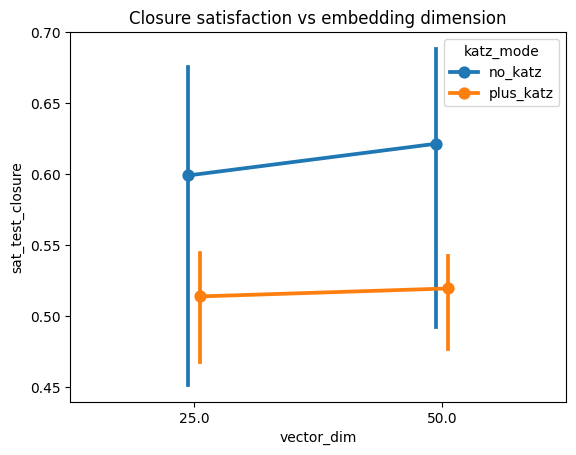

In [185]:
dfp = df.reset_index(drop=True).copy()

import seaborn as sns
import matplotlib.pyplot as plt

sns.pointplot(
    data=dfp,
    x="vector_dim",
    y="sat_test_closure",
    hue="katz_mode",
    dodge=True
)
plt.title("Closure satisfaction vs embedding dimension")
plt.show()


In [51]:
def normalize_hist(
    hist: pd.DataFrame,
    embed_type: str,
    katz_mode: str,
    vector_dim: int,
    predicate: str,
    hierarchy_source: str = "wordnet"
):
    df = hist.copy()

    df["embed_type"] = embed_type
    df["katz_mode"] = katz_mode          # no_katz / plus_katz
    df["predicate"] = predicate          # Hyp2 / Hyp3
    df["vector_dim"] = vector_dim
    df["hierarchy_source"] = hierarchy_source

    return df


In [52]:
df_ltn_all = pd.concat([
    normalize_hist(hist_A_cw,       "codeword",    "no_katz",   vector_dim=25,  predicate="Hyp2"),
    normalize_hist(hist_A_katzemb,  "katz_emb",    "no_katz",   vector_dim=25,  predicate="Hyp2"),
    normalize_hist(hist_A_teal,     "teal",        "no_katz",   vector_dim=100, predicate="Hyp2"),

    normalize_hist(hist_B_cw,       "codeword",    "plus_katz", vector_dim=25,  predicate="Hyp3"),
    normalize_hist(hist_B_katzemb,  "katz_emb",    "plus_katz", vector_dim=25,  predicate="Hyp3"),
    normalize_hist(hist_B_teal,     "teal",        "plus_katz", vector_dim=100, predicate="Hyp3"),
], ignore_index=True)


In [53]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import os

# =============================================================================
# CONFIG
# =============================================================================
BUNDLE_DIR = Path(
    "/content/bundles/bundles/poincare_sweeps/"
    "Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25"
)
SWEEPS_ROOT = BUNDLE_DIR.parent  # directory containing multiple sweep bundles
assert BUNDLE_DIR.exists(), BUNDLE_DIR
assert SWEEPS_ROOT.exists(), SWEEPS_ROOT

# =============================================================================
# PART 1 — BASELINE: load & normalize results.csv (your code, integrated)
# =============================================================================
res_path = BUNDLE_DIR / "results.csv"
if not res_path.exists():
    raise FileNotFoundError(f"Missing baseline results.csv in {BUNDLE_DIR}")

df = pd.read_csv(res_path)

print("Loaded baseline rows:", len(df))
print("Baseline columns:", list(df.columns))

# ---- katz_mode (baseline) ----
if "matrix" in df.columns:
    df["katz_mode"] = np.where(
        df["matrix"].astype(str).str.contains("katz", case=False, na=False),
        "plus_katz",
        "no_katz"
    )
else:
    df["katz_mode"] = "no_katz"

df["scenario"] = df["katz_mode"].map({"no_katz": "scnA", "plus_katz": "scnB"})

# ---- embed_type (baseline) ----
def infer_embed_type(row):
    m = str(row.get("matrix", "")).lower()
    mp = str(row.get("model_path", "")).lower()
    if "teal" in mp:
        return "teal"
    if "katz" in m:
        return "katz_scalar"
    if "codeword" in m:
        return "codeword"
    if "poincare" in m:
        return "poincare"
    return "unknown"

df["embed_type"] = df.apply(infer_embed_type, axis=1)

# ---- vector_dim (baseline) ----
if "vector_dim" not in df.columns:
    def infer_dim(p):
        p = str(p).lower()
        for d in [25, 50, 100]:
            if f"dim_{d}" in p or f"_{d}" in p:
                return d
        return np.nan
    df["vector_dim"] = df.get("model_path", "").apply(infer_dim)

df["hierarchy_source"] = "wordnet"
df["bundle_dir"] = str(BUNDLE_DIR)
df["bundle_tag"] = BUNDLE_DIR.name
df["family"] = "baseline"

KEEP = [
    "family",
    "bundle_tag",
    "bundle_dir",
    "run_tag",
    "clf",
    "matrix",
    "embed_type",
    "vector_dim",
    "katz_mode",
    "scenario",
    "hierarchy_source",
    "accuracy",
    "f1_macro",
    "f1_micro",
    "precision_macro",
    "recall_macro",
    "coverage_train",
    "coverage_test",
    "model_path",
]
KEEP = [c for c in KEEP if c in df.columns]
df_baseline = df[KEEP].copy()

out_path_baseline = BUNDLE_DIR / "baseline_results_scnA_scnB_with_katzemb_teal.csv"
df_baseline.to_csv(out_path_baseline, index=False)

print("\nSaved baseline summary to:", out_path_baseline)
print("Rows per (embed_type, scenario):")
print(df_baseline.groupby(["embed_type", "scenario"]).size())


# =============================================================================
# PART 2 — LTN: ingest from (A) cached hist_* objects (if present in memory)
#         + (B) sweep bundles containing ltn_hist_*.csv
# =============================================================================

def _infer_vecdim_from_embed_type(embed_type: str) -> float:
    et = str(embed_type).lower()
    if "teal" in et:
        return 100.0
    # your codeword/katzemb typically 25; poincare is bundle-dependent
    if "50" in et:
        return 50.0
    return 25.0

def _standardize_ltn_hist(df_hist: pd.DataFrame, embed_type: str, katz_mode: str,
                          predicate: str, bundle_tag: str, bundle_dir: str,
                          vector_dim: float, hierarchy_source: str = "wordnet",
                          model_path: str | None = None):
    out = df_hist.copy()
    out["family"] = "ltn"
    out["embed_type"] = embed_type
    out["katz_mode"] = katz_mode
    out["scenario"] = "scnB" if katz_mode == "plus_katz" else "scnA"
    out["predicate"] = predicate
    out["bundle_tag"] = bundle_tag
    out["bundle_dir"] = bundle_dir
    out["vector_dim"] = float(vector_dim) if vector_dim is not None else np.nan
    out["hierarchy_source"] = hierarchy_source
    if model_path is not None:
        out["model_path"] = model_path
    return out

ltn_frames = []

# ---------- (A) cached hist objects ----------
# We only add them if they exist in the notebook runtime.
_cached_specs = [
    # (varname, embed_type, katz_mode, predicate)
    ("hist_A_cw",      "codeword", "no_katz",   "Hyp2"),
    ("hist_A_katzemb", "katz_emb", "no_katz",   "Hyp2"),
    ("hist_A_teal",    "teal",     "no_katz",   "Hyp2"),
    ("hist_B_cw",      "codeword", "plus_katz", "Hyp3"),
    ("hist_B_katzemb", "katz_emb", "plus_katz", "Hyp3"),
    ("hist_B_teal",    "teal",     "plus_katz", "Hyp3"),
]

for varname, et, km, pred in _cached_specs:
    if varname in globals():
        h = globals()[varname]
        if isinstance(h, pd.DataFrame) and len(h) > 0:
            vd = _infer_vecdim_from_embed_type(et)
            ltn_frames.append(
                _standardize_ltn_hist(
                    h, embed_type=et, katz_mode=km, predicate=pred,
                    bundle_tag=BUNDLE_DIR.name, bundle_dir=str(BUNDLE_DIR),
                    vector_dim=vd,
                    hierarchy_source="wordnet",
                    model_path=None
                )
            )
            print(f"Added cached LTN history: {varname}  rows={len(h)}")
        else:
            print(f"WARNING: {varname} exists but is not a non-empty DataFrame")
    else:
        print(f"(skip) {varname} not found in globals()")

# ---------- (B) poincare sweep bundles: read ltn_hist*.csv per bundle ----------
def _read_model_path_from_results_csv(bundle: Path) -> str | None:
    p = bundle / "results.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p)
    if "model_path" in d.columns and d["model_path"].notna().any():
        return str(d["model_path"].dropna().iloc[0])
    return None

def _read_vector_dim_from_results_csv(bundle: Path) -> float | None:
    p = bundle / "results.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p)
    if "vector_dim" in d.columns and d["vector_dim"].notna().any():
        return float(d["vector_dim"].dropna().iloc[0])
    # fallback: parse from name
    m = re.search(r"Dim(\d+)", bundle.name)
    return float(m.group(1)) if m else None

def _infer_katz_mode_from_filename(name: str) -> str:
    name = name.lower()
    return "plus_katz" if ("plus_katz" in name or "_b_" in name or "scnb" in name) else "no_katz"

def _infer_predicate_from_filename(name: str) -> str:
    name = name.lower()
    if "hyp3" in name:
        return "Hyp3"
    if "hyp2" in name:
        return "Hyp2"
    return "Hyp?"

poincare_bundles = sorted([p for p in SWEEPS_ROOT.iterdir() if p.is_dir()])
print("\nFound sweep bundles:", len(poincare_bundles))

for b in poincare_bundles:
    # If you only want poincare bundles, keep this filter:
    if "Dim" not in b.name and "poincare" not in b.name.lower():
        continue

    model_path = _read_model_path_from_results_csv(b)
    vec_dim = _read_vector_dim_from_results_csv(b) or np.nan

    # pick up all ltn history files you saved
    hist_files = sorted(b.glob("ltn_hist_*.csv"))
    if not hist_files:
        continue

    for hf in hist_files:
        try:
            h = pd.read_csv(hf)
        except Exception as e:
            print("Could not read:", hf, "error:", e)
            continue

        km = _infer_katz_mode_from_filename(hf.name)
        pred = _infer_predicate_from_filename(hf.name)

        # poincare sweep embed_type fixed as poincare (these bundles are per model)
        ltn_frames.append(
            _standardize_ltn_hist(
                h, embed_type="poincare", katz_mode=km, predicate=pred,
                bundle_tag=b.name, bundle_dir=str(b),
                vector_dim=vec_dim,
                hierarchy_source="wordnet",
                model_path=model_path
            )
        )
        print(f"Added sweep LTN: {b.name} | {hf.name} rows={len(h)}")

# =============================================================================
# PART 3 — LTN: finalize tables
# =============================================================================
if ltn_frames:
    df_ltn_all = pd.concat(ltn_frames, ignore_index=True)
else:
    df_ltn_all = pd.DataFrame()
    print("WARNING: No LTN frames collected (no cached hist and no sweep hist files).")

# final epoch per run (per bundle/predicate/embed_type/katz_mode)
if len(df_ltn_all) > 0:
    group_cols = ["bundle_tag","embed_type","katz_mode","predicate","vector_dim","hierarchy_source"]
    df_ltn_final = (
        df_ltn_all
        .sort_values("epoch")
        .groupby(group_cols, as_index=False)
        .tail(1)
        .reset_index(drop=True)
    )
else:
    df_ltn_final = pd.DataFrame()

out_ltn = BUNDLE_DIR / "ltn_results_all_embeddings_and_poincare_sweeps.csv"
df_ltn_final.to_csv(out_ltn, index=False)
print("\nSaved LTN final-epoch table to:", out_ltn)
print("LTN rows:", len(df_ltn_final))
if len(df_ltn_final) > 0:
    print(df_ltn_final.groupby(["embed_type","katz_mode","predicate","vector_dim"]).size())

# =============================================================================
# PART 4 — optional combined table (baseline + LTN)
# =============================================================================
df_all = pd.concat([df_baseline, df_ltn_final], ignore_index=True, sort=False)
out_all = BUNDLE_DIR / "all_results_baseline_plus_ltn.csv"
df_all.to_csv(out_all, index=False)
print("\nSaved combined baseline+LTN table to:", out_all)
print("Total rows:", len(df_all))

# quick peek
display(df_ltn_final.head(10))


Loaded baseline rows: 6
Baseline columns: ['run_tag', 'model_path', 'vector_dim', 'kv_size', 'matrix', 'clf', 'max_path_len', 'coverage_train', 'coverage_test', 'pos_rate_train', 'pos_rate_test', 'acc', 'prec_macro', 'rec_macro', 'f1_macro', 'prec_1', 'rec_1', 'f1_1', 'sup_1', 'sup_0', 'pos_rate', 'pred_pos_rate', 'note']

Saved baseline summary to: /content/bundles/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25/baseline_results_scnA_scnB_with_katzemb_teal.csv
Rows per (embed_type, scenario):
embed_type   scenario
codeword     scnA        2
katz_scalar  scnB        2
poincare     scnA        2
dtype: int64
Added cached LTN history: hist_A_cw  rows=10
Added cached LTN history: hist_A_katzemb  rows=10
Added cached LTN history: hist_A_teal  rows=10
Added cached LTN history: hist_B_cw  rows=10
Added cached LTN history: hist_B_katzemb  rows=10
Added cached LTN history: hist_B_teal  rows=10

Found sweep bundles: 7
Added sweep LTN: Dim25__gensim_

,epoch,loss,sat,sat_pos,sat_neg,family,embed_type,katz_mode,scenario,predicate,...,sat_test_irreflex,sat_test_asymmetry,sat_test_closure,sat_test_pos,sat_test_neg,n_pos,n_neg,n_test_pos,n_test_neg,model_path
0,180,0.018820,0.981180,0.991416,0.997419,ltn,teal,no_katz,scnA,Hyp2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,180,0.016585,0.983415,0.991815,0.995547,ltn,teal,plus_katz,scnB,Hyp3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,180,0.022547,0.977453,0.987506,0.994180,ltn,codeword,no_katz,scnA,Hyp2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,180,0.043087,0.956913,0.976072,0.972436,ltn,katz_emb,no_katz,scnA,Hyp2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,180,0.023195,0.976805,0.986359,0.991693,ltn,codeword,plus_katz,scnB,Hyp3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,180,0.039049,0.960951,0.982485,0.982435,ltn,katz_emb,plus_katz,scnB,Hyp3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,199,0.024918,NaN,NaN,NaN,ltn,poincare,no_katz,scnA,Hyp2,...,0.617638,0.780975,0.688462,0.583567,0.0,332.0,193.0,606.0,0.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...
7,199,0.026679,NaN,NaN,NaN,ltn,poincare,no_katz,scnA,Hyp2,...,0.610805,0.766510,0.670430,0.657732,0.0,332.0,193.0,606.0,0.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...
8,199,0.024918,NaN,NaN,NaN,ltn,poincare,no_katz,scnA,Hyp2,...,0.617638,0.780975,0.688462,0.583567,0.0,332.0,193.0,606.0,0.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...
9,199,0.028843,NaN,NaN,NaN,ltn,poincare,plus_katz,scnB,Hyp3,...,0.616785,0.802772,0.544355,0.801702,0.0,332.0,193.0,606.0,0.0,/content/drive/MyDrive/HyperN/EMBD/Poincare_Ge...


In [3]:
import pandas as pd

df_ltn_final = pd.read_csv('/content/bundles/bundles/poincare_sweeps/Dim25__gensim_model_batch_size_10_burn_in_50_epochs_100_neg_15_dim_25/all_results_baseline_plus_ltn.csv')

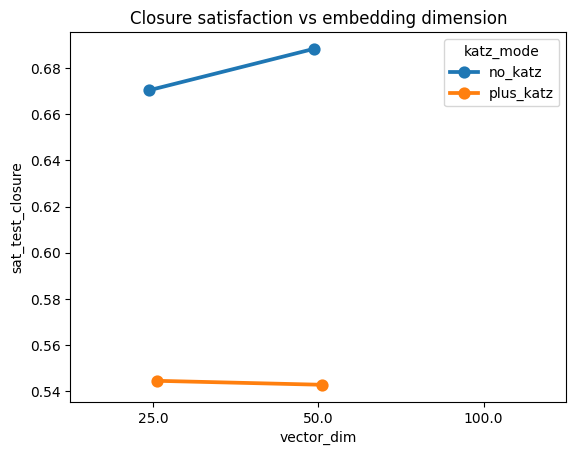

In [4]:
dfp = df_ltn_final.reset_index(drop=True).copy()

import seaborn as sns
import matplotlib.pyplot as plt

sns.pointplot(
    data=dfp,
    x="vector_dim",
    y="sat_test_closure",
    hue="katz_mode",
    dodge=True
)
plt.title("Closure satisfaction vs embedding dimension")
plt.savefig('closure_X_katz.png')
plt.show()


In [ ]:
dfp = df_ltn_final.reset_index(drop=True).copy()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dfp["vector_dim"] = pd.to_numeric(dfp["vector_dim"], errors="coerce")
dfp = dfp.dropna(subset=["vector_dim", "sat_test_closure", "embed_type", "katz_mode"]).copy()

for etype, dsub in dfp.groupby("embed_type"):
    plt.figure(figsize=(6, 4))
    sns.pointplot(
        data=dsub,
        x="vector_dim",
        y="sat_test_closure",
        hue="katz_mode",
        dodge=True,
        errorbar="se"
    )
    plt.title(f"Closure satisfaction vs embedding dimension — {etype}")
    plt.tight_layout()
    plt.show()


In [56]:
import statsmodels.formula.api as smf

m = smf.ols(
    "f1_macro ~ vector_dim + C(embed_type) + C(katz_mode)",
    data=df_out
).fit()

print(m.summary())


                            OLS Regression Results                            
Dep. Variable:               f1_macro   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     19.60
Date:                Sun, 21 Dec 2025   Prob (F-statistic):             0.0190
Time:                        20:45:34   Log-Likelihood:                 7.5978
No. Observations:                   6   AIC:                            -9.196
Df Residuals:                       3   BIC:                            -9.820
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [57]:
m = smf.ols(
    "f1_macro ~ vector_dim + C(embed_type)",
    data=df
).fit()
print(m.summary())


                            OLS Regression Results                            
Dep. Variable:               f1_macro   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     19.60
Date:                Sun, 21 Dec 2025   Prob (F-statistic):             0.0190
Time:                        20:45:45   Log-Likelihood:                 7.5978
No. Observations:                   6   AIC:                            -9.196
Df Residuals:                       3   BIC:                            -9.820
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [63]:
import numpy as np

# 1) find an existing "global" satisfaction column if present
GLOBAL_CANDIDATES = [
    "sat_train", "sat_overall", "sat_train_global", "sat_train_all", "sat_global",
    "sat_agg_train", "sat_train_total"
]
found = [c for c in GLOBAL_CANDIDATES if c in df_ltn_final.columns]

if found:
    df_ltn_final["sat_train_global"] = df_ltn_final[found[0]].astype(float)
    print("Using existing global sat column:", found[0], "-> sat_train_global")
else:
    # 2) otherwise build a global proxy from components you said you log
    # (only uses the columns that actually exist)
    parts = []
    for c in [
        "sat_train_trans",
        "sat_train_irreflex",
        "sat_train_asymmetry",
        "sat_train_closure",
        "sat_train_pos",
        "sat_train_neg",
    ]:
        if c in df_ltn_final.columns:
            parts.append(c)

    if not parts:
        raise ValueError(
            "No global sat column found and no component sats found. "
            "Available cols: " + ", ".join(df_ltn_final.columns)
        )

    # unweighted mean proxy (simple + stable)
    df_ltn_final["sat_train_global"] = df_ltn_final[parts].astype(float).mean(axis=1)
    print("Constructed sat_train_global as mean of:", parts)

# quick sanity
print(df_ltn_final[["embed_type","katz_mode","predicate","vector_dim","sat_train_global"]].head())


Constructed sat_train_global as mean of: ['sat_train_trans', 'sat_train_irreflex', 'sat_train_asymmetry', 'sat_train_closure', 'sat_train_pos', 'sat_train_neg']
  embed_type  katz_mode predicate  vector_dim  sat_train_global
0       teal    no_katz      Hyp2       100.0               NaN
1       teal  plus_katz      Hyp3       100.0               NaN
2   codeword    no_katz      Hyp2        25.0               NaN
3   katz_emb    no_katz      Hyp2        25.0               NaN
4   codeword  plus_katz      Hyp3        25.0               NaN


In [64]:
import statsmodels.formula.api as smf

REQ = ["sat_train_global", "embed_type", "vector_dim", "hierarchy_source", "katz_mode", "predicate"]
missing = [c for c in REQ if c not in df_ltn_final.columns]
assert not missing, f"Missing columns: {missing}"

m_global = smf.ols(
    formula="""
    sat_train_global ~
        vector_dim
        + C(embed_type)
        + C(hierarchy_source)
        + C(katz_mode)
        + C(predicate)
    """,
    data=df_ltn_final
).fit()

print(m_global.summary())


                            OLS Regression Results                            
Dep. Variable:       sat_train_global   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     47.43
Date:                Sun, 21 Dec 2025   Prob (F-statistic):            0.00537
Time:                        20:57:58   Log-Likelihood:                 31.709
No. Observations:                   6   AIC:                            -57.42
Df Residuals:                       3   BIC:                            -58.04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [65]:
df_delta = (
    df
    .pivot_table(
        index=["embed_type", "vector_dim"],
        columns="katz_mode",
        values="f1_macro"
    )
    .assign(delta=lambda x: x["plus_katz"] - x["no_katz"])
    .reset_index()
)


In [ ]:
smf.ols("delta ~ C(embed_type)", data=df_delta).fit()